In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import sctour as sct
import re
import anndata as ad
import statistics
import cosg
import celltypist
import sklearn
import plotly.express as px
import plotly.graph_objects as go
import re
import matplotlib.colors as mcolors
import kaleido
import pyucell as uc
import gseapy as gp
kaleido.get_chrome_sync()
sc.settings.n_jobs = 16
sc.settings.verbosity = 4
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='pdf')

import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['lines.linewidth'] = 0.5

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
Using last known good version of chrome


In [2]:
def filename_cell_type(cell_type):
    tmp = re.sub(' ','_',cell_type)
    tmp = re.sub('[+]','pos',tmp)
    tmp = re.sub('[-]', '_', tmp)
    tmp = re.sub('[/]', '_', tmp)
    return tmp

# 1 Hierarchy

## Full dataset

In [4]:
counts = pd.read_csv("/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label_counts.csv",index_col=0)

In [5]:
counts.head()

,Classification_L1,Classification_L2,Classification_L3,Classification_L4,Cell_counts
0,B cells,B cells,Atypical B cells,Atypical naïve B cells,11681
1,B cells,B cells,Atypical B cells,CD27+ IgD+ atypical memory B cells,28698
2,B cells,B cells,Atypical B cells,CD27+ IgD- atypical memory B cells,8928
3,B cells,B cells,Atypical B cells,CD27- IgD- atypical memory B cells,14701
4,B cells,B cells,Memory B cells,CD95 memory B cells,3090


In [6]:
counts.loc[:, 'angle'] = np.log10(counts['Cell_counts']).round(2)

In [7]:
fig_Cell_counts = px.sunburst(counts,
                  path=['Classification_L1', 'Classification_L2', 'Classification_L3','Classification_L4'], 
                  values='Cell_counts',
                 )

In [8]:
fig_angle = px.sunburst(counts,
                  path=['Classification_L1', 'Classification_L2', 'Classification_L3','Classification_L4'], 
                  values='angle',
                  branchvalues='total',
                 )

In [9]:
ids,labels,parents,cell_counts = fig_Cell_counts.data[0]['ids'],fig_Cell_counts.data[0]['labels'],fig_Cell_counts.data[0]['parents'],fig_Cell_counts.data[0]['values']

In [10]:
angle = fig_angle.data[0]['values']

In [ ]:
fig = go.Figure()
fig.add_trace(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=angle,
    text=[f"{int(count)}" for count in (cell_counts)],
    domain=dict(column=1),
    maxdepth=5,
    branchvalues='total',
    insidetextorientation='radial',
    marker=dict(
        colors=angle,
        colorscale='RdBu',
        cmid=np.average(angle)
    ),
    texttemplate='<b>%{label} </b> <br> Num: %{text}'
))

fig.update_layout(
    margin =dict(t=10, b=10, r=10, l=10),
    width=1000,
    height=1000
)

fig.show()

In [12]:
fig.write_html('/home/liyanguo/MyImmuCell/08_supp_outputs/hierarchy_with_counts/Immune_cell_hierarchy_with_counts.html')
fig.write_image('/home/liyanguo/MyImmuCell/08_supp_outputs/hierarchy_with_counts/Immune_cell_hierarchy_with_counts.pdf',scale=5,
                engine="kaleido")

/tmp/ipykernel_1968668/227289604.py:2: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.


Chromium init'ed with kwargs {}
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Temp directory created: /tmp/tmpqspohpwr.
Opening browser.
Temp directory created: /tmp/tmpppaiub92.
Temporary directory at: /tmp/tmpppaiub92
Conforming 1 to file:///tmp/tmpqspohpwr/index.html
Waiting on all navigates
All navigates done, putting them all in queue.
Getting tab from queue (has 1)
Got 41CE
Processing fig.pdf
Sending big command for fig.pdf.
Sent big command for fig.pdf.
Reloading tab 41CE before return.
Putting tab 41CE back (queue size: 0).
Waiting for all cleanups to finish.
Exiting Kaleido
TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.
Cancelling tasks.
Exiting Kaleido/Choreo
Closing bro

## Cell type sub

In [13]:
counts = pd.read_csv("/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label_counts.csv",index_col=0)
Classification='Classification_L2'

In [14]:
cell_types = counts[Classification].unique()
cell_types

array(['B cells', 'HSPC', 'ILCs', 'DC', 'Granulocytes', 'Monocytes',
       'Platelets', 'CD4+ T cells', 'DN T cells', 'MAIT', 'NKT',
       'Non-MAIT/NKT CD8+ T cells', 'γδ T cells'], dtype=object)

In [28]:
def cell_type_hierarchy(cell_type):
    filtered_df = counts.copy()
    filtered_df = filtered_df.query(f'{Classification}=="{cell_type}"')
    #避免有的簇太少，扇形太小
    filtered_df=filtered_df.copy()
    filtered_df.loc[:, 'angle'] = np.log10(filtered_df['Cell_counts']).round(2)
    fig_Cell_counts = px.sunburst(filtered_df,
                      path=['Classification_L2', 'Classification_L3','Classification_L4'], 
                      values='Cell_counts',
                     )
    fig_angle = px.sunburst(filtered_df,
                      path=['Classification_L2', 'Classification_L3','Classification_L4'], 
                      values='angle',
                     )
    
    ids,labels,parents,cell_counts = fig_Cell_counts.data[0]['ids'],fig_Cell_counts.data[0]['labels'],fig_Cell_counts.data[0]['parents'],fig_Cell_counts.data[0]['values']
    angle = fig_angle.data[0]['values']
    
    fig = go.Figure()
    fig.add_trace(go.Sunburst(
        ids=ids,
        labels=labels,
        parents=parents,
        values=angle,
        text= [count for count in zip(cell_counts)],
        domain=dict(column=1),
        maxdepth=5,
        branchvalues='total',
        insidetextorientation='radial',
        marker=dict(
            colors=cell_counts,
            colorscale='RdBu',
            cmid=np.average(cell_counts),
        ),
        texttemplate='<b>%{label} </b> <br> Counts: %{text}',
        hovertemplate='<b>%{label} </b> <br> Counts: %{text}',
    ))
    fig.update_layout(
        margin =dict(t=10, b=10, r=10, l=10),
        width=800,
        height=800
    )
    #fig.show()
    
    #save
    filename = filename_cell_type(cell_type)
    fig.write_html(f'/home/liyanguo/MyImmuCell/08_supp_outputs/hierarchy_with_counts/{filename}_hierarchy_with_counts.html')
    fig.write_image(f'/home/liyanguo/MyImmuCell/08_supp_outputs/hierarchy_with_counts/{filename}_hierarchy_with_counts.pdf',scale=5)

In [29]:
from multiprocessing import Pool
with Pool(6) as p:
    p.map(cell_type_hierarchy, cell_types)

Chromium init'ed with kwargs {}
Chromium init'ed with kwargs {}
Chromium init'ed with kwargs {}
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Chromium init'ed with kwargs {}
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Temp directory created: /tmp/tmp_65n0v57.
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Temp directory created: /tmp/tmptit91_5r.
Temp directory created: /tmp/tmpinqpcr1p.
Opening browser.
Chromium init'ed with kwargs {}
Temp directory created: /tmp/tmpidlta8t8.
Opening browser.
Opening browser.
Found chromium path: /home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-pa

# 2. Full dataset update and ## Visualization

In [18]:
dataset='Full_dataset'

In [19]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{dataset}/'
sc.settings.figdir = obj_path

In [20]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [9]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed='r')

In [ ]:
adata.obs['SampleID'] = adata.obs['SampleID'].astype(str)

In [15]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [33]:
if (adata.obs.index == indices.index).all():
    adata.obs['Classification_L2'] = indices['Classification_L2']
    adata.obs['Classification_L3'] = indices['Classification_L3']
adata.strings_to_categoricals()

In [34]:
adata.strings_to_categoricals()

... storing 'Classification_L2' as categorical
... storing 'Classification_L3' as categorical


In [11]:
groupby = 'Classification_L2'

In [19]:
adata.obs[groupby].value_counts()

Classification_L2
Granulocytes                 28525525
CD4+ T cells                  6470674
Non-MAIT/NKT CD8+ T cells     5040279
ILCs                          4939470
Monocytes                     3580489
B cells                       1851292
γδ T cells                     933420
DC                             305272
MAIT                           242121
NKT                             80981
HSPC                            18927
DN T cells                       8276
Platelets                        7437
Name: count, dtype: int64

In [24]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'B cells',
    
    'CD4+ T cells',
    'Non-MAIT/NKT CD8+ T cells',
    'MAIT',
    'γδ T cells',
    'NKT',
    'DN T cells',
    'ILCs',
    
    'Monocytes',
    'DC',
    
    'Granulocytes',
    
    'HSPC',
    'Platelets',
])

In [38]:
palette_dict = {'B cells':mcolors.to_rgb('#ffe2db'),
                'CD4+ T cells':mcolors.to_rgb('#fffac9'),
                'Non-MAIT/NKT CD8+ T cells':mcolors.to_rgb('#CBE5DE'),
                'MAIT':mcolors.to_rgb('#EED0E0'),
                'γδ T cells':mcolors.to_rgb('#f0c1f5'), 
                'NKT':mcolors.to_rgb('#AED0DF'),
                'DN T cells':mcolors.to_rgb('#D2EBC8'), 
               
                'ILCs':mcolors.to_rgb('#6495ED'),
               
                'Monocytes':mcolors.to_rgb('#7DBFA7'),
                'DC':mcolors.to_rgb('#EE934E'), 
            
                
                'Granulocytes':mcolors.to_rgb('#c496ff'), 
                
                'HSPC':mcolors.to_rgb('#D1352B'),
                
                'Platelets':mcolors.to_rgb('#B383B9')
              }

In [ ]:
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='pdf')

In [42]:
fig = sc.pl.umap(
    adata,
    color=groupby,
    palette = palette_dict,
    size=0.05,
    save=f'_{dataset}_{groupby}',show=False,
    title=f"{dataset}_{groupby}",
    legend_loc="on data",
    legend_fontsize=4,frameon=False,
    #return_fig=True
)

In [30]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 10000,
                                                 by = 'Classification_L3',
                                                 return_index = True,random_state=0)

adata[cell_index]

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(2, 2, figsize=(18, 12),constrained_layout=True)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby='Classification_L3', rotation=90,size=0.1,palette="pastel",inner=None,linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby='Classification_L3', rotation=90,size=0.1,palette="pastel",inner=None,linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_apop', groupby='Classification_L3', rotation=90,size=0.1,palette="pastel",inner=None,linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby='Classification_L3', rotation=90,size=0.1,palette="pastel",inner=None,linewidth=0,ax=axs[1,1], show=False)
fig.tight_layout()
plt.savefig(f'{obj_path}{dataset}_{groupby}_metadata')

# 3. B cells

In [19]:
Classification='Classification_L2'
dataset='B_cells'
groupby='Classification_L4'

In [20]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [21]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [22]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [23]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [24]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [25]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [26]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical
... storing 'leiden_cluster' as categorical


In [27]:
adt.strings_to_categoricals()

In [29]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [30]:
adata.obs[groupby].value_counts()

Classification_L4
Naïve B cells                         1012593
Non-switched memory B cells            453374
Switched Memory B cells                139914
Early memory B cells                   108056
IGKChi Plasma cells                     29048
CD27+ IgD+ atypical memory B cells      28698
CD27- IgD- atypical memory B cells      14701
Atypical naïve B cells                  11681
CD27+ IgD- atypical memory B cells       8928
Plamsablasts                             4405
IGLL5hi Plasma cells                     3381
CD95 memory B cells                      3090
Name: count, dtype: int64

In [31]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Naïve B cells',
    'Early memory B cells',
    'Non-switched memory B cells',
    'Switched Memory B cells',
    'CD95 memory B cells',
    
    'Atypical naïve B cells',
    'CD27+ IgD+ atypical memory B cells',
    'CD27+ IgD- atypical memory B cells',
    'CD27- IgD- atypical memory B cells',
    
    'Plamsablasts',
    'IGKChi Plasma cells',
    'IGLL5hi Plasma cells',
])

In [32]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Naïve B cells',
    'Early memory B cells',
    'Non-switched memory B cells',
    'Switched Memory B cells',
    'CD95 memory B cells',
    
    'Atypical naïve B cells',
    'CD27+ IgD+ atypical memory B cells',
    'CD27+ IgD- atypical memory B cells',
    'CD27- IgD- atypical memory B cells',
    
    'Plamsablasts',
    'IGKChi Plasma cells',
    'IGLL5hi Plasma cells',
])

## Visualization

In [51]:
sc.pl.umap(
    adata,
    color=groupby,
    legend_fontsize=8,ncols=2,frameon=False,
    size=0.5,legend_loc='on data',
    save=f'_{dataset}_{groupby}',show=False
    )

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 43 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'I', 'K', 'L', 'M', 'N', 'P', 'S', 'a', 'b', 'c', 'd', 'e', 'five', 'g', 'h', 'hyphen', 'i', 'idieresis', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'p', 'plus', 'r', 's', 'seven', 'space', 't', 'two', 'v', 'w', 'y']
Glyph IDs:   [0, 1, 2, 3, 14, 16, 21, 24, 26, 28, 36, 37, 38, 39, 40, 42, 44, 46, 47, 48, 49, 51, 54, 68, 69, 70, 71, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 89, 90, 92, 177]
Closed glyph list over 'GSUB': 43 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'I', 'K', 'L', 'M', 'N', 'P', 'S', 'a', 'b', 'c', 'd', 'e', 'five', 'g', 'h', 'hyphen', 'i', 'idieresis', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'p', 'plus', 'r', 's', 'seven', 'space', 't', 'two', 'v', 'w', '

<Axes: title={'center': 'Classification_L4'}, xlabel='UMAP1', ylabel='UMAP2'>

### Marker of adt

In [33]:
marker_adt_dict=["CD19",'HLA-DR','IgD','IgM','CD27','CD62L',
         'CD11c',]

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 55 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'idieresis', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'underscore', 'v', 'w', 'x', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 14, 16, 17, 19, 20, 21, 23, 24, 25, 26, 28, 36, 37, 38, 39, 40, 42, 43, 44, 46, 47, 48, 49, 51, 53, 54, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 177]
Closed glyph list over 'MATH': 55 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'fo

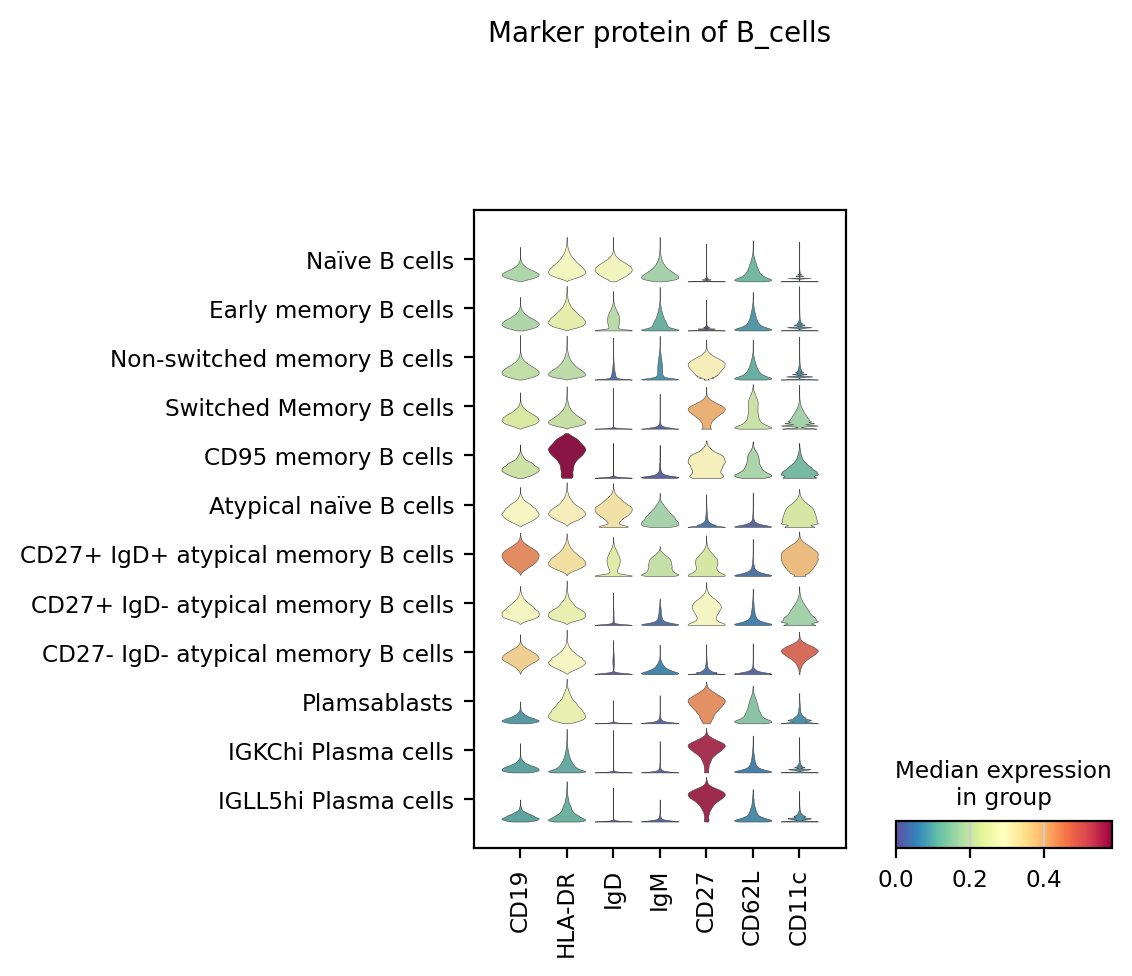

In [48]:
sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var',save='Marker_of_adt',
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [43]:
Marker_gene_dict=['IGHM','IGHD','PAX5','MS4A1',
                  'TCL1A','IL4R','FCER2',
                  'IGHG1','IGHG2','IGHG3','IGHG4','IGHA1','IGHA2','IGHE',
                  'AIM2','S100A10','CRIP1',
                  'FAS','ENTPD1','CD40','COCH','ACTG1','HOPX',

                  'TBX21','ITGAX','FCRL5','SIGLEC6','SOX5','FGR','LILRB2',
                  
                  'JCHAIN','PRDM1','TNFRSF17','CD38',
                  'MKI67','STMN1',
                  'IGKC','IGLL5','IGLV2-14','IGLV1-44'
                 ]

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 66 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'idieresis', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'w', 'x', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 14, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 57, 59, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 177]
Closed glyph list over 'MATH': 72 glyphs after
Glyph names: ['.notde

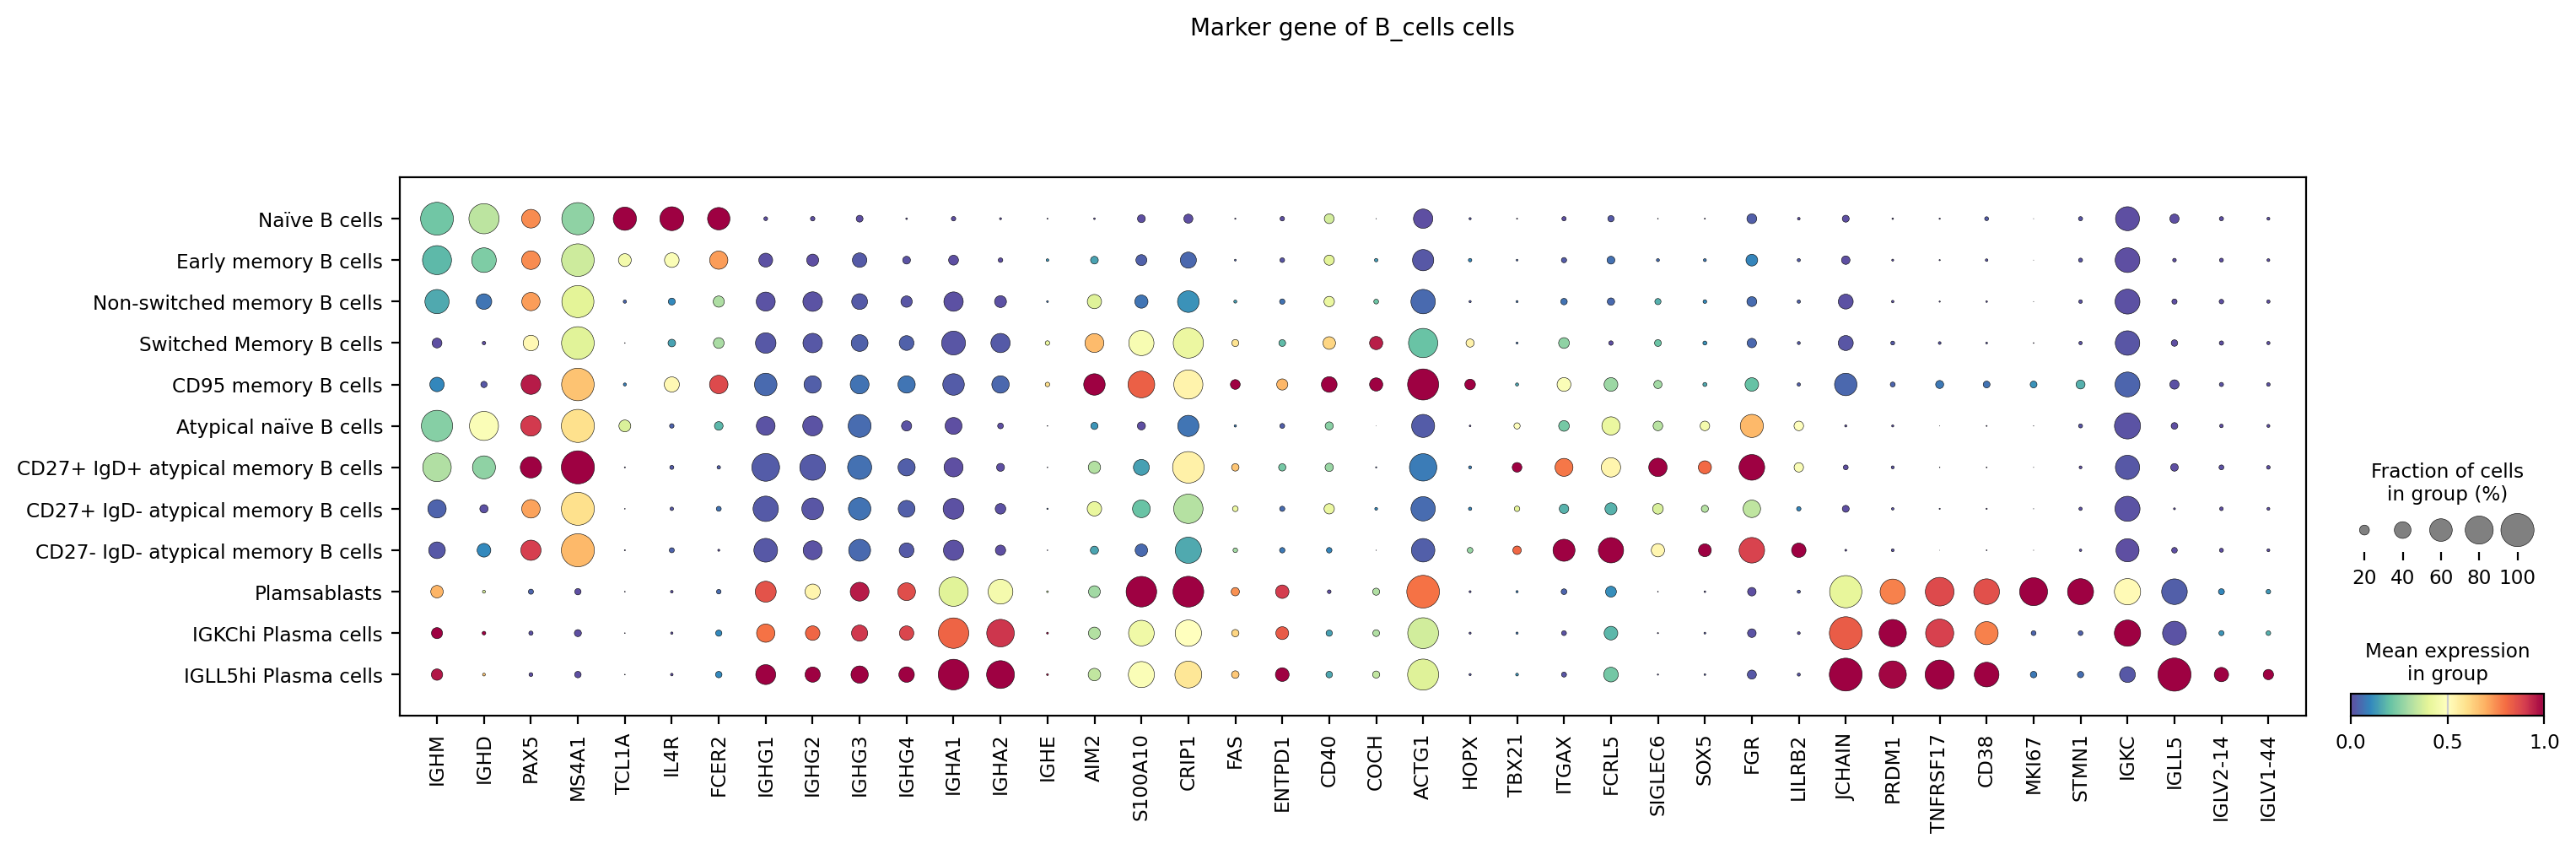

In [47]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset} cells",
    standard_scale='var',save='Marker_of_genes',
)

# 4. HSPC

In [457]:
Classification='Classification_L3'
dataset='HSPC'
groupby='Classification_L4'

In [458]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [459]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [460]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [461]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [462]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [464]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [465]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [466]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [468]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [469]:
adata.obs[groupby].value_counts()

Classification_L4
HSC/MPP    6807
CLP        5592
MkP        4781
CILCP      1540
MEP         207
Name: count, dtype: int64

In [470]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'HSC/MPP','CLP','CILCP','MEP','MkP',
])

In [471]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'HSC/MPP','CLP','CILCP','MEP','MkP',
])

## Visualization

In [274]:
genes_to_check ={
'HSC': ['HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'HSPC_marker_{groupby}',
             cmap='Spectral_r')

In [276]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'HSPC_TF_{groupby}',
             cmap='Spectral_r')

### Marker of adt

In [444]:
marker_adt_dict=["CD45RA",'HLA-DR','CD25','CD127']

In [ ]:
sc.pl.umap(adt, color=["CD45RA",'HLA-DR','CD25',groupby], frameon=False, ncols=4, vmax="p99",layer='clr')

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Protein expression of {dataset}"
)

In [ ]:
sc.pl.matrixplot(
    adt,
    marker_adt_dict,
    groupby=groupby,
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",layer='clr',
    title=f"Marker protein of {dataset}",
)

In [ ]:
sc.pl.dotplot(
    adt,
    groupby=groupby,
    var_names=marker_adt_dict,
    layer='clr',
    expression_cutoff=1,
    dot_min=0.1,
    title="Marker protein of B cells",
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [495]:
Marker_gene_dict={'HSC/MPP':['CD34','PROM1','SPINK2','SMIM24','CSF3R','AVP',
                             'C1QTNF4','NOG','ITGA4','ITGB7'],
                  'CLP':['DNTT','HOPX','HOXA9','MME','JCHAIN','RUNX2',],#CLP
                  'CILCP':['TCF7','ID2','NFIL3',
                           'ETS1','RUNX3',
                           'AHR','RORC','KIT','ACY3','TOX','IL2RB','TBX21'],#不是NKP
                  
                  'MEP':['APOC1','HBD','CD38','SLC40A1','GATA1','GFI1B'],#MEP
                  'MkP':['MPL','GATA2','PLEK','FCER1A',],#MkP
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset} cells",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
sc.pl.dotplot(adata, ['RUNX3','KLRB1'，],
              standard_scale='var',groupby=groupby)

In [ ]:
#KEGG_HEMATOPOIETIC_cell_Lineage的富集查看
#除了4和6，lin neg
cell_dict = {
    'MEP':['4'],#CD45RA-CD7- CD34+ SPINK2- MPL=CD110+ FLT3=CD135- HBD  CSF3R+ FCER1A+ RUNX1+ CD38+确认 PLEK- PF4- KIT 'APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'
    'MkP':['1'],#CD45RA-CD7- CD34+ SPINK2- MPL=CD110+ FLT3=CD135- HBD  CSF3R+ FCER1A+ RUNX1+ CD38+确认 PLEK+ PF4-  'GATA2','FCER1A','PBX1','CYTL1','SLC40A1'
    'CLP':['3',],#CD45RA+ CCR7 CCR9 CD7- IL7R- CD34+ SPINK2+ SOX4- KIT- DNTT+ FLT3+ LMO4+ MME+ CCR7+ RUNX2+ CD79Alow VPREB1low JCHAIN+ ITGA6low CD38- 
    'HSC/MPP':['0',],#CD45RA- AVP+ GATA2+ RUNX1+ FCER1A+
    'CILCP':['2',],#CD45RA+ CD34- KIT+ NFIL3+ TOX+ ITGAX+ TCF7+ RORC+ IL7R- CD3E+ AHR+  CD27- HLA-DR+ CD122=IL2RB-(核心，表明不是NKP) TBX21- EOMES- ITGAM+ GATA3- ID2+
    }

# https://www.cell.com/immunity/fulltext/S1074-7613(18)30246-2  CILCP

#CD7- 	CD34+ CD133+ SPI1 MYB MPL=CD110+ CSF3R=G-CSFR+  CD45RA-
#'Circulating MEPs'
#CD34+ CD38+ CD123- FLT3=CD135+ CD45RA-   CD38-low  AVP 
#'Circulating MkPs'#megakaryocyte  progenitor cells  PLEK

#CD7low CD34-  KIT+ CD133- FLT3=CD135+ PLD4  SPIB SPI1+(出骨髓的) CD45RA- IL7R- LMO4 MHCII+
#'Circulating MDPs'#common dendritic cell progenitors
#CCR7 RUNX2  JCHAIN   IGHM IGHD SOX4 GATA1- CD38- RORC

#CD7- 	CD34+  CD133+ KIT- FLT3=CD135+ PU.1/SPI1+(出骨髓的) MME CD45RA- IL7R-  ADA 
#'Circulating CLPs'
#CCR7  RUNX2  JCHAIN DNTT/tdt  IGHM IGHD SOX4 GATA1- CD38- LMO4

#Lin- CD7+ KIT+ CD96+ IL7R+ SELPLG+(CLP前往胸腺的因子) CD45RA+  SOX4-  FLT3=CD135-  CXCR4low SELL
#'Circulating NK/TPs'
#TCF7 IL32 ETS1（表明已经过了CLP阶段）  IL2RA=CD25+
#ILC2表达GATA3,但是需要KIT-/CRTH2+,所以不是
#ILC3需要RORC和AHR+，不是

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
# ATXN1（SCA1）
#T-restricted progenitors, circulating T progenitors, T-committed precursors PMID: 21251013, PMID: 17222572
#GMP 需要MPO
#https://www.nature.com/articles/s41392-022-01167-9 STTT
#https://www.nature.com/articles/s41467-022-29675-w    CD34+EPCR(PROCR)+(CD38/CD45RA)−   CD34+CD38−CD45RA− HSC    CD90+CD49f(ITGA6)+ HSC and CD90−CD49f− MPPs      CD90+CD49f+ and CD90−CD49f+ HSC
#https://www.cell.com/cell/fulltext/S0092-8674(24)00408-2#author-highlights-abstract MEP  AVP
#https://www.bdbiosciences.com/content/dam/bdb/marketing-documents/BD_Multiparametric_Immuno_Stem_Cells_AppNote.pdf
#https://link.springer.com/article/10.1007/s00018-018-2865-1#Sec3 NK ILC问题
# From stem cell to T cell: one route or many? 
# 血液中 HSC 的频率随昼夜节律振荡而波动，在光明开始后 5 小时达到峰值，在天黑后至少 5 小时达到峰值。我们在早上取样的（PMID: 18256599）
#  Exacting experiments to uncover the mechanisms of lymphoid progenitor homing from the BM to the thymus have been hampered by difficulties in identifying the relevant progenitor population

# 5. Non-NK ILCs

In [501]:
Classification='Classification_L3'
dataset='Non_NK_ILCs'
groupby='Classification_L4'

In [502]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [503]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [504]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [505]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [506]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [508]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [509]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [510]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [512]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [513]:
adata.obs[groupby].value_counts()

Classification_L4
ILCP    9928
ILC2    7634
Name: count, dtype: int64

In [514]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'ILCP','ILC2',
])

In [515]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'ILCP','ILC2',
])

## Visualization

In [425]:
genes_to_check ={
'HSC': ['HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

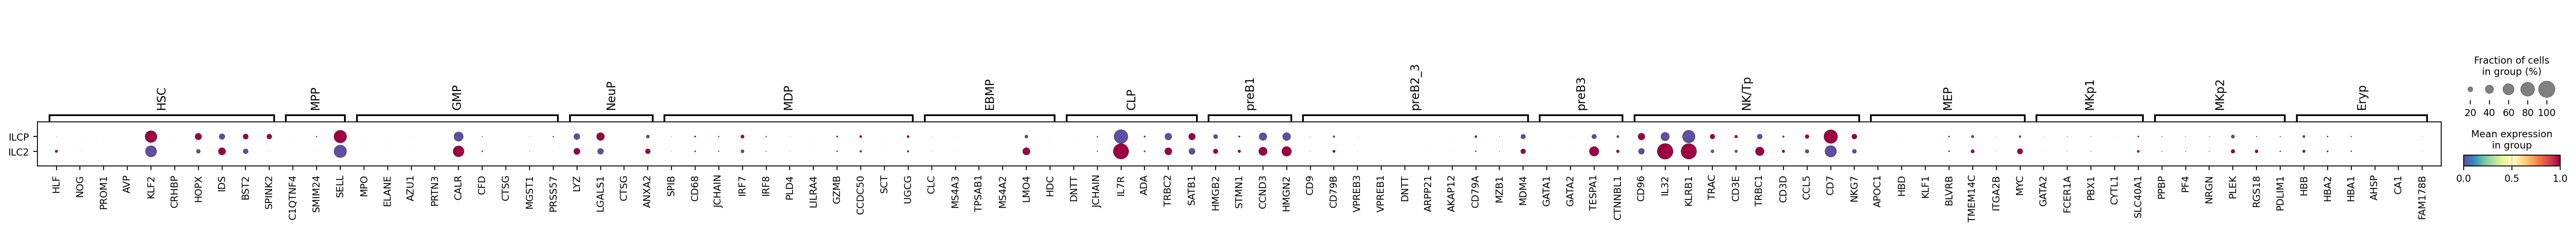

In [426]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'HSPC_marker_{groupby}',
             cmap='Spectral_r')

In [427]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'HSPC_TF_{groupby}',
             cmap='Spectral_r')

### Marker of adt

In [525]:
marker_adt_dict=["CD45RA",'CD127','CD25','CD161','HLA-DR','CD56']

In [ ]:
sc.pl.umap(adt, color=["CD45RA",'HLA-DR','CD25',groupby], frameon=False, ncols=4, vmax="p99",layer='clr')

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [532]:
Marker_gene_dict={'Marker':['IL7R','KLRB1','ITGA4','ITGB7','KLRD1','GZMK','KLRF1','TBX21'],
                  'ILCP':['AHR','KIT','RORC','IL2RB','ID2','FCER1G','TNFRSF4','CD7','TYROBP',
                         'XCL1','XCL2','FCER1G',],#CLP
                  'ILC2':['PTGDR2','GATA3','RORA','ZBTB16','LTB','IL2RA','MAF',],
}

In [ ]:
sc.pl.dotplot(adata, Marker_gene_dict,
              standard_scale='var',
              groupby=groupby)

# 6. NK_cells

In [534]:
Classification='Classification_L3'
dataset='NK_cells'
groupby='Classification_L4'

In [535]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [536]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [537]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [538]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [539]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [541]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [542]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [543]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [545]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [546]:
adata.obs[groupby].value_counts()

Classification_L4
Adaptive NK cells         2352029
CD56dim NK cells          2312983
CD56bright NK cells        219168
Proliferative NK cells      37728
Name: count, dtype: int64

In [547]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'CD56bright NK cells','CD56dim NK cells','Adaptive NK cells','Proliferative NK cells'
])

In [548]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'CD56bright NK cells','CD56dim NK cells','Adaptive NK cells','Proliferative NK cells'
])

## Visualization

### Marker of adt

In [552]:
marker_adt_dict=["CD45RA",'CD56','CD16','CD161',
                 'CD127','CD62L','CD366','CD11c','CD27']

In [ ]:
sc.pl.umap(adt, color=["CD45RA",'HLA-DR','CD25',groupby], frameon=False, ncols=4, vmax="p99",layer='clr')

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [587]:
Marker_gene_dict={'CD56bright NK cells':['NCAM1','FCGR3A','GZMK','TCF7','TNFRSF11A','IL7R','SELL','IL2RB','XCL1','XCL2'],
                  'CD56dim NK cells':['FCER1G','CD160','KLRB1','SPON2','KLRG1',
                                      'PRF1','GNLY','GZMB',
                                     'CX3CR1','CXCR2'],
                  'Adaptive NK cells':['CD3E','KLRC2','CCL5','GZMH','IL32','CD3D','CD3G','CD52','KLRC3','PRDM1'],
                  'Proliferative NK cells':['MKI67','STMN1','ITGB7','CD38'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
signature= {
    'HLA-dependent inhibitory receptors':['KIR3DL1', 'KIR3DL2', 'LILRB1','LAG3','KIR2DL1', 'KIR2DL3'],#
    'HLA-independent inhibitory receptors':['PDCD1', 'SIGLEC7', 'CD300A', 'CD96', 'IL1RAPL1', 'TIGIT', 'HAVCR2'],
    'HLA-dependent activating receptors':['KIR2DL4', 'CD160', 'KLRC2'],
    'HLA-independent activating receptors':['NCR3', 'NCR1',  'CRTAM','FCGR3A'],#'KLRK1',
}
sc.pl.dotplot(adata, signature,
             groupby=groupby,
             dendrogram=False,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

# 7. CD4_T_cells

In [105]:
Classification='Classification_L2'
dataset='CD4pos_T_cells'
groupby='Classification_L3'

In [106]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [107]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [108]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [109]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [110]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [112]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [113]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [114]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [116]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [117]:
adata.obs[groupby].value_counts()

Classification_L3
Naïve CD4+ T cells        2944753
Help memory T cells       2409636
Cytotoxic CD4+ T cells     745111
CD4+ Treg                  371174
Name: count, dtype: int64

In [118]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Naïve CD4+ T cells','Help memory T cells','Cytotoxic CD4+ T cells','CD4+ Treg'
])

In [119]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Naïve CD4+ T cells','Help memory T cells','Cytotoxic CD4+ T cells','CD4+ Treg'
])

## Visualization

### Marker of adt

In [25]:
marker_adt_dict=["CD45RA",'CD3','CD4',
                 'CD197','CD62L',
                 'CD27','CD28','CD25',
                 'CD127','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [40]:
Marker_gene_dict=['KLF2','FOXO1','RUNX1',]#维持静息

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [36]:
Marker_gene_dict={'Naïve CD4+ T cells':['CCR7','SELL','TCF7','IL6ST'],
                  'Help memory T cells':['ITGB1','GZMK','KLRB1','CCR6','AQP3','GATA3','GPR183','IL7R'],
                  'CD4+ Treg':['IL2RA','FOXP3','IKZF2','TIGIT','CTLA4',],
                  'Cytotoxic CD4+ T cells':['GZMB','GZMH','GNLY','PRF1','CCL5','FGFBP2',],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 8. Help memory T cells

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [164]:
Classification='Classification_L3'
dataset='Help_memory_T_cells'
groupby='Classification_L4'

In [145]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [146]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [147]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [148]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [149]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [151]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [152]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [153]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [155]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [194]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'CD27+ Th1','CD27- Th1', 
    'CD27+ Th17','CD27- Th17', 
    'Th1/Th17',
    'Th2','Th22',
    'Tfh',
    'Proliferative help memory T cells',
])

In [195]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'CD27+ Th1','CD27- Th1', 
    'CD27+ Th17','CD27- Th17', 
    'Th1/Th17',
    'Th2','Th22',
    'Tfh',
    'Proliferative help memory T cells',
])

## Broadly Help memory T cells

In [159]:
cell_dict = {'Tfh':['Tfh'],
             'Th1':['CD27+ Th1','CD27- Th1', ],
             'Th17':['CD27+ Th17','CD27- Th17', ],
             'Th1/Th17':['Th1/Th17'],
             'Th2':['Th2'],
             'Th22':['Th22'],
             'Proliferative help memory T cells':['Proliferative help memory T cells'],
}

In [160]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs['Classification_L4']).isin(cell_dict[i])
    adata.obs.loc[ind,'Broadly Help memory T cells'] = i

In [162]:
adata.obs['Broadly Help memory T cells'].isna().value_counts()

Broadly Help memory T cells
False    2409636
Name: count, dtype: int64

In [163]:
adata.obs['Broadly Help memory T cells'].value_counts()

Broadly Help memory T cells
Tfh                                  1211669
Th17                                  564973
Th1/Th17                              315375
Th1                                   143579
Th2                                    86571
Th22                                   64229
Proliferative help memory T cells      23240
Name: count, dtype: int64

## Visualization

In [196]:
groupby='Classification_L4'

### Marker of adt

In [197]:
marker_adt_dict=["CD45RA",'CD4',
                 'CD161','CD196','CD279',
                 'CD27','CD28',
                 'CD197','CD62L',
                 'CD25','CD127','HLA-DR'
                 ]

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [199]:
Marker_gene_dict={'Pan marker':['CCR6','CXCR3','CCR4','CCR10','KLRB1','GZMK','ITGB1'],
                  'CD27+ Th1':['PDCD1','EOMES','TBX21','IFNG','CCR5','STAT4'],
                  'CD27- Th1':['GZMH','GZMB','PRF1','GNLY','CCL5','CST7','NKG7','GZMA',],#可能代表向衰老型发育的
                  'CD27- Th17':['RORC','USP10','MAP3K4','PDE4D','AQP3','MAL','LTB','BCL2'],
                  'CD27+ Th17':['PTPN13','NR1D1',],
                  'Th1/Th17':['IL18RAP','IL18R1',
                              'DPP4',
                              'LYAR','ID2','MYBL1','BHLHE40','HOPX','KLRG1',
                              ],
                  'Th2':['PTGDR2','GATA3','STAT6','IL4R',
                         'TNFRSF4','TNFSF10',],
                  'Th22':['AHR','CNTNAP1','LMNA','LGALS1','PI16','LGALS3','LMO4','ITGB1'],
                  'Tfh':['CXCR5','IL6ST','CCR7','SELL','LEF1','TCF7'],
                  'Proliferative help memory T cells':['MKI67','BIRC5','RRM2'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [190]:
Marker_gene_dict=['KLF2','FOXO1','RUNX1']#维持静息

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 9. Cytotoxic_CD4pos_T_cells

In [255]:
Classification='Classification_L3'
dataset='Cytotoxic_CD4pos_T_cells'
groupby='Classification_L4'

In [256]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [257]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [258]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [259]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [260]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [262]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [263]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [264]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [266]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [267]:
adata.obs[groupby].value_counts()

Classification_L4
GZMB+ CD4+ terminal effector T cells       717617
CD4+ Temra                                  14511
HLA-DRhi CD4+ terminal effector T cells     12670
Proliferative cytotoxic CD4+ T cells          313
Name: count, dtype: int64

In [268]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'GZMB+ CD4+ terminal effector T cells',
    'HLA-DRhi CD4+ terminal effector T cells',
    'CD4+ Temra',
    'Proliferative cytotoxic CD4+ T cells', 
])

In [269]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'GZMB+ CD4+ terminal effector T cells',
    'HLA-DRhi CD4+ terminal effector T cells',
    'CD4+ Temra',
    'Proliferative cytotoxic CD4+ T cells', 
])

## Visualization

### Marker of adt

In [281]:
marker_adt_dict=["CD45RA",'CD3','CD4',
                 'CD27','CD28',
                 'CD127','HLA-DR',
                 'CD279','CD56']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [303]:
Marker_gene_dict=['GZMA','GZMB','GZMH','GNLY','PRF1','CCL5',
                  'FGFBP2','HLA-DRB1','CD74',
                  'KLRK1','KLRF1','TYROBP','KLRD1',
                  'STMN1',]

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Row scaled\nexpression",
    standard_scale='group'
)

# 10. CD4pos_Treg

In [309]:
Classification='Classification_L3'
dataset='CD4pos_Treg'
groupby='Classification_L4'

In [310]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [311]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [312]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [313]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [314]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [316]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [317]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [318]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [320]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [321]:
adata.obs[groupby].value_counts()

Classification_L4
Memory CD4+ Treg           239193
Naïve CD4+ Treg             76314
KLRB1+ CD4+ Treg            31848
HLA-DRhi CD4+ Treg          14793
Proliferative CD4+ Treg      9026
Name: count, dtype: int64

In [322]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
   'Naïve CD4+ Treg', 'Memory CD4+ Treg','KLRB1+ CD4+ Treg','HLA-DRhi CD4+ Treg', 'Proliferative CD4+ Treg',
])

In [323]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Naïve CD4+ Treg', 'Memory CD4+ Treg','KLRB1+ CD4+ Treg','HLA-DRhi CD4+ Treg', 'Proliferative CD4+ Treg',
])

## Visualization

### Marker of adt

In [330]:
marker_adt_dict=["CD45RA",'CD3','CD4','CD25',
                 'CD197','CD62L',
                 'CD27','CD28',
                 'CD161','CD278','CD279',
                 'CD127','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [356]:
Marker_gene_dict={'Naïve CD4+ Treg':['TCF7','CCR7','IL6ST'],
                  'Memory CD4+ Treg':['KLF6','IKZF2','RTKN2'],
                  'KLRB1+ CD4+ Treg':['KLRB1','IKZF3','MAF','LIMS1','AQP3','GPR183',],
                  'HLA-DRhi CD4+ Treg':['HLA-DRB1','CD74','LGALS1'],
                  'Proliferative CD4+ Treg':['MKI67',],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.stacked_violin(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 11. Non_MAIT_NKT_CD8pos_T_cells

In [369]:
Classification='Classification_L2'
dataset='Non_MAIT_NKT_CD8pos_T_cells'
groupby='Classification_L3'

In [370]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [371]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [372]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [373]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [374]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [376]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [377]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [378]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [380]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [381]:
adata.obs[groupby].value_counts()

Classification_L3
CD8+ Tem              3667044
Naïve CD8+ T cells    1235329
CD8+ Tcm               135079
CD8+ Treg                2827
Name: count, dtype: int64

In [382]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Naïve CD8+ T cells','CD8+ Tcm','CD8+ Tem','CD8+ Treg',
])

In [383]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Naïve CD8+ T cells','CD8+ Tcm','CD8+ Tem','CD8+ Treg',
])

## Visualization

### Marker of adt

In [384]:
marker_adt_dict=["CD45RA",'CD3','CD8',
                 'CD197','CD62L',
                 'CD27','CD28','CD25',
                 'CD127','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [398]:
Marker_gene_dict={'Naïve CD8+ T cells':['CCR7','TCF7','IL6ST','LEF1',
                                       'NT5E',],
                  'CD8+ Tcm':['CCR4','GATA3','GPR183','IL7R','IL4R','LTB'],
                  'CD8+ Tem':['GZMA','GZMB','GZMH','GZMK','PRF1','GNLY','NKG7',
                              'CCL5','CX3CR1','TBX21',],
                  'CD8+ Treg':['FOXP3','IL2RA','TIGIT','CTLA4'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 12. CD8pos_Tcm

In [400]:
Classification='Classification_L3'
dataset='CD8pos_Tcm'
groupby='Classification_L4'

In [401]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [402]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [403]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [404]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [405]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [407]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [408]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [409]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [411]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [412]:
adata.obs[groupby].value_counts()

Classification_L4
CCR4+ CD8+ Tcm    103039
CCR4- CD8+ Tcm     32040
Name: count, dtype: int64

In [413]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'CCR4+ CD8+ Tcm','CCR4- CD8+ Tcm',
])

In [414]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'CCR4+ CD8+ Tcm','CCR4- CD8+ Tcm',
])

## Visualization

### Marker of adt

In [417]:
marker_adt_dict=["CD45RA",'CD3','CD8',
                 'CD197','CD62L',
                 'CD27','CD28','CD25',
                 'CD127']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [431]:
Marker_gene_dict={'CCR4+ CD8+ Tcm':['CCR4','GATA3','TNFSF10','LGALS1','IL6R','IL4R',
                                   'TIGIT'],
                  'CCR4- CD8+ Tcm':['CCL5','GBP5','IKZF3','GZMK','ZNF683',],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 13. CD8pos_Tem

In [433]:
Classification='Classification_L3'
dataset='CD8pos_Tem'
groupby='Classification_L4'

In [434]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [435]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [436]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [437]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [438]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [440]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [441]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [442]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [444]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [445]:
adata.obs[groupby].value_counts()

Classification_L4
CD8+ Temra                           1134447
GZMB+ CD8+ Tem                       1105417
HLA-DRhi CD8+ Tem                     747000
GZMK+ CD8+ Tem                        666573
Proliferative CD8+ memory T cells      13607
Name: count, dtype: int64

In [453]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'GZMK+ CD8+ Tem','GZMB+ CD8+ Tem','HLA-DRhi CD8+ Tem','CD8+ Temra','Proliferative CD8+ memory T cells'
])

In [454]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'GZMK+ CD8+ Tem','GZMB+ CD8+ Tem','HLA-DRhi CD8+ Tem','CD8+ Temra','Proliferative CD8+ memory T cells'
])

## Visualization

### Marker of adt

In [459]:
marker_adt_dict=["CD45RA",'CD3','CD8',
                 'CD197','CD62L',
                 'CD27','CD28','CD25','CD161','CD279',
                 'CD127','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [461]:
Marker_gene_dict={'GZMK+ CD8+ Tem':['GZMK','TCF7','LTB','IL7R'],
                  'GZMB+ CD8+ Tem':['GZMA','GZMB','GZMH','GZMK','PRF1','GNLY','NKG7',
                                    'CCL5','ZNF683','TBX21',],
                  'HLA-DRhi CD8+ Tem':['HLA-DRB1','HLA-DRA','CD74',],
                  'CD8+ Temra':['KLRC2','IKZF2','NCR1','KLRC3','KLRF1','KLRB1',],
                  'Proliferative CD8+ memory T cells':['MKI67','STMN1'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 14. MAIT

In [3]:
Classification='Classification_L3'
dataset='MAIT'
groupby='Classification_L4'

In [22]:
adata = sc.read_h5ad('/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R6/MAIT/MAIT_HVG.h5ad')

In [21]:
adata2 = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/MAIT/MAIT_scRNA_count_HVG.h5ad')

In [14]:
adata.obsm["X_TOTALVI"]=np.load(f"/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R6/MAIT/MAIT_X_TOTALVI.npy")

In [ ]:
sc.pl.umap(adata)

In [23]:
adata

AnnData object with n_obs × n_vars = 284925 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'L4_leiden_TOTALVI_0.1', 'L4_leiden_TOTALVI_0.5', 'L4_leiden_TOTALVI_1', 'L4_leiden_TOTALVI_1.5', 'L4_leiden_TOTALVI_0.3', 'L4_leiden_TOTALVI_0.8'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'X_TOTALVI', 'X_umap'

In [19]:
adata2

AnnData object with n_obs × n_vars = 242033 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [ ]:
sc.pl.umap(adata,color='L4_leiden_TOTALVI_0.8')

In [4]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [5]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [6]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [7]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [468]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [469]:
if (adt.obs.index == indices.index).all():
    del adt.obs['Classification_L1'],adt.obs['Classification_L2'],adt.obs['Classification_L3'],adt.obs['Classification_L4'],
    adt.obs = adt.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [470]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [471]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [472]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [474]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [475]:
adata.obs[groupby].value_counts()

Classification_L4
CD27+ MAIT    207265
CD27- MAIT     34101
CD56+ MAIT       755
Name: count, dtype: int64

In [477]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'CD27+ MAIT','CD27- MAIT','CD56+ MAIT'
])

In [478]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'CD27+ MAIT','CD27- MAIT','CD56+ MAIT'
])

## Visualization

### Marker of adt

In [481]:
marker_adt_dict=["CD45RA",'CD3','CD8','CD56',
                 'CD27','CD28','CD196','CD161',
                 'CD127']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [506]:
Marker_gene_dict={'CD27+ MAIT':['CD8A','CD8B','CD27','GZMK','CCL5','KLRB1',],
                  'CD27- MAIT':['LGALS3','LGALS1','S100A10','CRIP1','S100A4','GNLY','RORC',
                               'DPP4','NCR3','CCR6','IL7R'],
                  'CD56+ MAIT':['NCAM1','PRF1','CXCR6']
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 16. γδ_T_cells

In [578]:
Classification='Classification_L2'
dataset='γδ_T_cells'
groupby='Classification_L3'

In [579]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [580]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [581]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [582]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

/tmp/ipykernel_3432552/1858493966.py:1: DtypeWarning: Columns (5,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)


In [583]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [585]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [586]:
adata.strings_to_categoricals()

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical
... storing 'Celltype_L2_L3_Refine' as categorical
... storing 'leiden_cluster' as categorical
... storing 'receptor_type' as categorical
... storing 'Refined_label' as categorical
... storing 'Celltype_L3_L4_Refine' as categorical
... storing 'Celltype_L4_L5_Refine' as categorical
... storing 'Celltype_L4_L5_Refine_R2' as categorical
... storing 'Celltype_L4_L5_Refine_R3' as categorical
... storing 'Celltype_L4_L5_Refine_R4' as categorical
... storing 'Celltype_L4_L5_Refine_R5' as categorical
... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [587]:
adt.strings_to_categoricals()

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical
... storing 'Celltype_L2_L3_Refine' as categorical
... storing 'leiden_cluster' as categorical
... storing 'receptor_type' as categorical
... storing 'Refined_label' as categorical
... storing 'Celltype_L3_L4_Refine' as categorical
... storing 'Celltype_L4_L5_Refine' as categorical
... storing 'Celltype_L4_L5_Refine_R2' as categorical
... storing 'Celltype_L4_L5_Refine_R3' as categorical
... storing 'Celltype_L4_L5_Refine_R4' as categorical
... storing 'Celltype_L4_L5_Refine_R5' as categorical
... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [588]:
adata.obs[groupby].value_counts()

Classification_L3
Vδ2+ T cells    893855
Vδ1+ T cells     39565
Name: count, dtype: int64

In [589]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Vδ1+ T cells','Vδ2+ T cells',
])

In [590]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Vδ1+ T cells','Vδ2+ T cells',
])

## 

### Marker of adt

In [591]:
marker_adt_dict=["CD45RA",'CD3','CD4','CD8',
                 'CD62L',
                 'CD27','CD28',
                 'CD127','CD16']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [593]:
Marker_gene_dict={'Vδ1+ T cells':['TRDV1','TCF7','LTB','LEF1','SOX4','CCR7'],
                  'Vδ2+ T cells':['TRDV2','TRGV9','KLRB1','CCL5','GZMA','GZMK','GNLY','PRF1','NKG7','FCGR3A'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 17. Vδ2pos_T_cells

In [595]:
Classification='Classification_L3'
dataset='Vδ2pos_T_cells'
groupby='Classification_L4'

In [596]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [597]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [598]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [599]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [600]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [602]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [603]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [604]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [606]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [607]:
adata.obs[groupby].value_counts()

Classification_L4
GZMB+ Vδ2+ T cells            630298
GZMK+ Vδ2+ T cells            224338
CD62Lhi GZMK+ Vδ2+ T cells     39016
Proliferative Vδ2+ T cells       203
Name: count, dtype: int64

In [608]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'GZMK+ Vδ2+ T cells','CD62Lhi GZMK+ Vδ2+ T cells','GZMB+ Vδ2+ T cells','Proliferative Vδ2+ T cells',
])

In [609]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'GZMK+ Vδ2+ T cells','CD62Lhi GZMK+ Vδ2+ T cells','GZMB+ Vδ2+ T cells','Proliferative Vδ2+ T cells',
])

### Marker of adt

In [625]:
marker_adt_dict=["CD45RA",'CD3','CD4','CD8',
                 'CD62L',
                 'CD27','CD28',
                 'CD127','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [627]:
Marker_gene_dict={'Pan marker':['TRDV2','TRGV9'],
                  'GZMK+ Vδ2+ T cells':['GZMK','LTB','IL7R','TCF7'],
                  'CD62Lhi GZMK+ Vδ2+ T cells':['SELL','HLA-DRA','CD74','HLA-DRB1'],
                  'GZMB+ Vδ2+ T cells':['GZMB','GZMH','GZMA','GZMK','GNLY','PRF1','NKG7',
                                        'ZNF683','CCL5','FCGR3A'],
                  'Proliferative Vδ2+ T cells':['MKI67','STMN1'],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 18. Vδ1pos_T_cells

In [633]:
Classification='Classification_L3'
dataset='Vδ1pos_T_cells'
groupby='Classification_L4'

In [634]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [635]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad",backed=True)

In [636]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad",backed=True)

In [637]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [638]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [640]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [641]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [642]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [644]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [645]:
adata.obs[groupby].value_counts()

Classification_L4
Naïve Vδ1+ T cells              14980
GZMK+ effector Vδ1+ T cells     10359
SOX4+ Vδ1+ T cells               6557
KLRC2+ effector Vδ1+ T cells     4313
CD279+ SOX4+ Vδ1+ T cells        3356
Name: count, dtype: int64

In [647]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Naïve Vδ1+ T cells',
    'SOX4+ Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells',
    'GZMK+ effector Vδ1+ T cells','KLRC2+ effector Vδ1+ T cells',
])

In [648]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Naïve Vδ1+ T cells',
    'SOX4+ Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells',
    'GZMK+ effector Vδ1+ T cells','KLRC2+ effector Vδ1+ T cells',
])

## Visualization

### Marker of adt

In [657]:
marker_adt_dict=["CD45RA",'CD3','CD4','CD8',
                 'CD197','CD62L',
                 'CD27','CD28',
                 'CD279',
                 'CD127',]

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [674]:
Marker_gene_dict={'Naïve Vδ1+ T cells':['CCR7','SELL','TCF7','IL7R'],
                  'SOX4+ Vδ1+ T cells':['SOX4','CCR9','TOX2','STMN1'],
                  'CD279+ SOX4+ Vδ1+ T cells':['ZNF683','MME','PDCD1','KLRB1'],
                  'GZMK+ effector Vδ1+ T cells':['GZMK','GZMA','NKG7','PRF1','GZMB'],
                  'KLRC2+ effector Vδ1+ T cells':['KLRC2','KLRC3','KLRK1','NCR3','CCL5','S100A4',
                                                  'IL32',],
}

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby,
    swap_axes=False,
    dendrogram=False,
    cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 19. NKT_cells

In [232]:
Classification='Classification_L3'
dataset='NKT'
groupby='Classification_L4'

In [233]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [234]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [235]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [236]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [237]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [239]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [240]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [241]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [243]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [244]:
adata.obs[groupby].value_counts()

Classification_L4
vNKT    80176
iNKT      805
Name: count, dtype: int64

In [245]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'iNKT','vNKT',
])

In [246]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'iNKT','vNKT',
])

## Visualization

### Marker of adt

In [247]:
marker_adt_dict=["CD45RA",'CD56','CD3','CD4','CD8','CD161','CD27','CD28','CD127']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [249]:
Marker_gene_dict={'iNKT':['TRAV24','TRAJ18','TRBV25-1','CCR7','CD4','CD8A','CD8B'],
                  'vNKT':['CD3D','CD3E','NCAM1','KLRD1','IL2RB',
                          'KLRC2','TYROBP','ZNF683','IKZF2',
                          'GNLY','PRF1','SPON2','GZMB','GZMH','CCL5','IL32',
                          'KLRB1','KLRG1','IL7R'
                          ]
                 }

In [ ]:
ax = sc.pl.stacked_violin(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

## 2.2 TCR

In [699]:
import scirpy as ir
import muon as mu

In [693]:
adata_tcr= sc.read_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/scTCR_MyImmuCell.h5ad")

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


In [711]:
adata_tcr = adata_tcr[adata_tcr.obs.index.isin(adata.obs.index)]

View of AnnData object with n_obs × n_vars = 62113 × 0
    uns: 'chain_indices'
    obsm: 'airr', 'chain_indices'

In [713]:
mdata_tcr = mu.MuData({"gex": adata, "airr": adata_tcr})

In [714]:
ir.pp.index_chains(mdata_tcr)

Filtering chains...
Indexing VJ chains...
    Sorting chains by junction_aa
    Sorting chains by junction
    Skip sorting by consensus_count because field not present
    Skip sorting by duplicate_count because field not present
    Sorting chains by umi_count
Indexing VDJ chains...
    Sorting chains by junction_aa
    Sorting chains by junction
    Skip sorting by consensus_count because field not present
    Skip sorting by duplicate_count because field not present
    Sorting chains by umi_count
build result array


In [719]:
mdata_tcr

MuData object with n_obs × n_vars = 80981 × 38606
  2 modalities
    gex:	80981 x 38606
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset', 'Classification_L4', 'Classification_L3', 'Classification_L2', 'Classification_L1', 'UMAP_1', 'UMAP_2', 'Batch', 'receptor_type_BCR', 'VJ_1_v_call_BCR', 'VJ_1_j_call_BCR', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'VJ_1_locus', 'VJ_1_v_call', 'VJ_1_j_call', 'VJ_1_junction_aa', 'VJ_1_junction', 'VJ_1_umi_count', 'VDJ_1_locus', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_junction_aa', 'VDJ_1_junction', 'VDJ_1_umi_count'
      obsm:	'X_TOTALVI', 'X_umap'
    airr:	62113 x 0
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

In [ ]:
#这里没有multichain
ir.pl.group_abundance(mdata_tcr, groupby="airr:chain_pairing", target_col="gex:Classification_L4")

In [ ]:
with ir.get.airr_context(mdata_tcr, "v_call"):
    ir.pl.group_abundance(
        mdata_tcr,
        groupby="VDJ_1_v_call",# as x axis
        target_col="dataset",# as fill in ggplot
        normalize=True,
        max_cols=10,
    )

In [665]:
#根据TCR识别部分细胞；TCR作为充分非必要条件
data_tcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scTCR_MyImmuCell.csv",index_col=0,
                       #usecols=[0,1,5,6]
                      )
data_bcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scBCR_MyImmuCell.csv",index_col=0,
                       usecols=[0,1,5,6]
                      )

In [670]:
adata.obs = adata.obs.join(data_tcr, how='left')#TCR
#adata.obs = adata.obs.join(data_bcr, how='left',rsuffix='_BCR')#BCR

In [ ]:
adata.strings_to_categoricals()

In [ ]:
adata.obs.receptor_type.value_counts()

In [ ]:
adata.obs.receptor_type.value_counts()

In [ ]:
adata.obs['VDJ_1_v_call'].value_counts()

In [ ]:
adata.obs.groupby(['VDJ_1_v_call', groupby]).size()

In [683]:
adata.obs[groupby].value_counts()

Classification_L4
vNKT    80176
iNKT      805
Name: count, dtype: int64

# 19. Monocytes

In [677]:
Classification='Classification_L2'
dataset='Monocytes'
groupby='Classification_L4'

In [678]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [679]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [680]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [681]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [682]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [684]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [685]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [686]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [688]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [689]:
adata.obs[groupby].value_counts()

Classification_L4
Core classical monocytes     2402622
Non-classical monocytes       510244
GBP1+ classical monocytes     360407
Intermediate monocytes        303118
ISG+ classical monocytes        4098
Name: count, dtype: int64

In [690]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Core classical monocytes',
    'GBP1+ classical monocytes','ISG+ classical monocytes',
    'Intermediate monocytes',
    'Non-classical monocytes',
])

In [691]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Core classical monocytes',
    'GBP1+ classical monocytes','ISG+ classical monocytes',
    'Intermediate monocytes',
    'Non-classical monocytes',
])

## Visualization

### Marker of adt

In [692]:
marker_adt_dict=["CD45RA",'CD14','CD16','CD4',
                 'CD62L','CD11c','HLA-DR']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [699]:
Marker_gene_dict={'Core classical monocytes':['FCGR3A','CD14','LYZ','VCAN',
                                              'FCN1','S100A8','S100A12','ITGAM'],
'GBP1+ classical monocytes':['STAT1','FCGR1A','GBP1','GBP2','GBP5',],
'ISG+ classical monocytes':['ISG15','IFIT1','IFI44','PADI4'],
'Intermediate monocytes':['HLA-DRA','CD74','HLA-DQB1'],
'Non-classical monocytes':['CDKN1C','CSF1R','SIGLEC10','CD79B','SELPLG'],
                 }

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 19. DC

In [705]:
Classification='Classification_L2'
dataset='DC'
groupby='Classification_L4'

In [706]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [707]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [708]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [709]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [710]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [712]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [713]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [714]:
adt.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [716]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [717]:
adata.obs[groupby].value_counts()

Classification_L4
CD1C+ cDC2    119782
pDCs           86987
CD14+ cDC2     85385
cDC1            7780
ASDC            5160
LAMP3+ DC        178
Name: count, dtype: int64

In [719]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'pDCs','ASDC','cDC1','CD1C+ cDC2','CD14+ cDC2','LAMP3+ DC',
])

In [720]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'pDCs','ASDC','cDC1','CD1C+ cDC2','CD14+ cDC2','LAMP3+ DC',
])

## Visualization

### Marker of adt

In [728]:
marker_adt_dict=["CD45RA",'CD4','CD56','CD272',
                 'CD183','CD366',
                 'CD11c','HLA-DR','CD14','CD16']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [740]:
Marker_gene_dict={'pDCs':['CLEC4C','LILRA4','GZMB','JCHAIN','IRF8',],
                  'ASDC':['SIGLEC6','AXL','SOX4','CD5',],
                  'cDC1':['CLEC9A','XCR1','IDO1','FLT3','ENPP1'],
                  'CD1C+ cDC2':['CLEC10A','CD1C','MRC1','FCER1A','IL18'],
                  'CD14+ cDC2':['CD14','VCAN','S100A9','FCN1',],
                  'LAMP3+ DC':['LAMP3','CCL19','CCR7','IDO2',],
                 }

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 19. Basophils

In [26]:
Classification='Classification_L3'
dataset='Basophils'
groupby='Classification_L4'

In [27]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [28]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [29]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [30]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

In [31]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [32]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [33]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical
... storing 'leiden_cluster' as categorical


In [36]:
adt.strings_to_categoricals()

In [37]:
adata.obs[groupby].value_counts()

Classification_L4
Basophils    34153
Name: count, dtype: int64

In [38]:
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].values

In [39]:
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(6,6), format='pdf')
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

## Visualization

### Marker of adt

In [592]:
marker_adt_dict=["CD45RA",'CD56','CD3','CD4','CD8','CD161','CD27','CD28','CD127']

In [ ]:
sc.pl.umap(adt, color=[groupby], frameon=False, ncols=4,layer='clr')

In [ ]:
ax = sc.pl.stacked_violin(
    adt, adt.var_names, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='viridis',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [618]:
Marker_gene_dict=['IL4','LTC4S','FCGR1A','GATA2','IL3RA','KIT','CD69','CXCL8']

In [ ]:
ax = sc.pl.stacked_violin(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [41]:
Level_counts_frac =  pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_sample_counts_frac_clinicl_table.xlsx",index_col=0)

In [42]:
info_cols = [
        'SampleID',"ClinicalID","Ten_year_intervals"
    ]

In [43]:
metadata = Level_counts_frac[info_cols]#.set_index("ClinicalID")

In [44]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Ten_year_intervals']))
adata.obs['Ten_year_intervals'] = adata.obs['SampleID'].map(mapping_dict)

In [54]:
Marker_gene_dict=['IL4','IL1RL1','AREG','PTGER3']

In [ ]:
ax = sc.pl.violin(
    adata, Marker_gene_dict, groupby='Ten_year_intervals',
    cmap='Spectral_r'
)

# 19. Mast_cells

In [ ]:
Classification='Classification_L3'
dataset='Mast_cells'
groupby='Classification_L4'

In [ ]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [ ]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [ ]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [ ]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [ ]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [ ]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [ ]:
adata.strings_to_categoricals()

In [ ]:
adt.strings_to_categoricals()

In [ ]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [ ]:
adata.obs[groupby].value_counts()

In [ ]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'iNKT','vNKT',
])

In [ ]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'iNKT','vNKT',
])

## Visualization

### Marker of adt

In [ ]:
marker_adt_dict=["CD45RA",'CD56','CD3','CD4','CD8','CD161','CD27','CD28','CD127']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var'
)

### Marker of gene

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
Marker_gene_dict={'iNKT':['TRAV24','TRAJ18','TRBV25-1','CCR7','CD4','CD8A','CD8B'],
                  'vNKT':['CD3D','CD3E','NCAM1','KLRD1','IL2RB',
                          'KLRC2','TYROBP','ZNF683','IKZF2',
                          'GNLY','PRF1','SPON2','GZMB','GZMH','CCL5','IL32',
                          'KLRB1','KLRG1','IL7R'
                          ]
                 }

In [ ]:
ax = sc.pl.stacked_violin(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var'
)

# 19. Low_density_Neutrophils

In [177]:
Classification='Classification_L3'
dataset='LDNs'
groupby='Classification_L4'

In [178]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [80]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [81]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [82]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

In [83]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [84]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [85]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical
... storing 'leiden_cluster' as categorical


In [86]:
adt.strings_to_categoricals()

In [87]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [88]:
adata.obs[groupby].value_counts()

Classification_L4
MMP8+ CD177+ iLDNs     14866
MPO+ CD177- iLDNs      12844
MPO- CD177- iLDNs      10660
Proliferative iLDNs    10573
MMP8+ CD177+ mLDNs     10544
CD177int iLDNs          9629
MMP9+ CD177+ iLDNs      8975
MPO+ mLDNs              5566
Proliferative mLDNs     2115
Name: count, dtype: int64

In [89]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'MPO+ CD177- iLDNs',
    'MPO- CD177- iLDNs',
    'CD177int iLDNs',
    'MMP8+ CD177+ iLDNs',
    'MMP9+ CD177+ iLDNs',
    'Proliferative iLDNs',

    'MPO+ mLDNs',
    'MMP8+ CD177+ mLDNs',
    'Proliferative mLDNs'
])

In [90]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'MPO+ CD177- iLDNs',
    'MPO- CD177- iLDNs',
    'CD177int iLDNs',
    'MMP8+ CD177+ iLDNs',
    'MMP9+ CD177+ iLDNs',
    'Proliferative iLDNs',

    'MPO+ mLDNs',
    'MMP8+ CD177+ mLDNs',
    'Proliferative mLDNs'
])

In [91]:
adata_LDN_aucell = adata.copy()

In [98]:
adata

AnnData object with n_obs × n_vars = 85772 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset', 'Classification_L4', 'Classification_L3', 'Classification_L2', 'Classification_L1', 'leiden_cluster', 'UMAP_1', 'UMAP_2', 'Batch'
    obsm: 'X_umap'

## Visualization

### Marker of adt

In [92]:
marker_adt_dict=["CD45RA",'CD16','CD4','CD127','CD62L','CD183','CD11c','HLA-DR','CD14']

In [ ]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var',
    save='marker_adt_dict'
)

### Marker of gene

In [247]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [250]:
Marker_gene_dict={'Core marker':['CEACAM8','MME','CSF3R',
                                'MKI67',
                                
                                'FUT4','ANPEP',
                                ],
                  'TF':['RUNX1','SPI1','GFI1','CEBPE','CEBPB',],
                  
                  'Granules_effctor':['MPO','ELANE','PRTN3','DEFA3',
                                      'CHI3L1','CAMP','LTF','LCN2',
                                      'MMP8','MMP9','PADI4','CD177','ORM1',
                                      'LIMD2','S100A12',
                                      'CXCL8','ALPL',
                                       ],
                 'Migration':['PECAM1','CXCR2','CXCR4'],
                 'Receptor':['IFNAR1','IFNAR2','IFNGR1','IFNGR2',
                              'C5AR1','TLR4','FPR1','NR3C1'],
                 }
#多个转录因子RUNX1,CEBPE,CEBPB,GFI1, SPI1

In [ ]:
ax = sc.pl.dotplot(
    adata, Marker_gene_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='var',
     save='S3A marker_gene_dict'
)

In [252]:
Marker_gene_dict2 = {'Immunesuppress':['ARG1','CYBB','CD47','SIRPA',"TGFB1",
                                       'VSIR','TSC22D3',"STAT3","LGALS3"
                                    ]
                    }

In [ ]:
ax = sc.pl.stacked_violin(
    adata, Marker_gene_dict2, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='viridis',
    title=f"Immunesuppress of {dataset},Column scaled\nexpression",
    standard_scale='var',
    save='3_immuneS marker_gene_dict'
)

### gene variation trend

In [254]:
Level_counts_frac =  pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_sample_counts_frac_clinicl_table.xlsx",index_col=0)

info_cols = [
        'SampleID',"ClinicalID",'DonorID', "Gender", "Ten_year_intervals",
        "Pregnancy", 'Pregnancy stage', "Sampling time",'Age_in_Years'
    ]

metadata = Level_counts_frac[info_cols]#.set_index("ClinicalID")

In [255]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Ten_year_intervals']))
adata.obs['Ten_year_intervals'] = adata.obs['SampleID'].map(mapping_dict)

In [256]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Age_in_Years']))
adata.obs['Age_in_Years'] = adata.obs['SampleID'].map(mapping_dict)

In [257]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Pregnancy stage']))
adata.obs['Pregnancy stage'] = adata.obs['SampleID'].map(mapping_dict)

In [258]:
adata_sub = adata[adata.obs[groupby]=='MMP8+ CD177+ iLDNs',]

In [ ]:
ax = sc.pl.violin(
    adata, 'CXCR4', groupby='Pregnancy stage', cmap='Spectral_r'
)

In [ ]:
gene = 'PADI4'

df = pd.DataFrame({
        'exp':adata[:, gene].X.toarray().flatten(),
        'Ten_year_intervals': adata.obs['Ten_year_intervals'],
        'celltype': adata.obs['Classification_L4']
    })
heatmap_data = df.groupby(['celltype', 'Ten_year_intervals'])['exp'].mean().unstack().T
heatmap_data = heatmap_data.reindex(['2-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79','80-89', '90+'])
#sns.set(style="white", context="talk")
plt.figure(figsize=(10,5))

colors = ['#EF7B20','#2B9865','#89554A','#CA2928','#2171A9','#B0B760','#1EB3C3','#CE75AC',
          
          '#9FD2A8',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371']

for i, col in enumerate(heatmap_data.columns.to_list()):
    plt.plot(heatmap_data.index, heatmap_data[col],
             label=col,
             color=colors[i],
             marker="o",markersize=3,
             linewidth=2)

sns.despine()
plt.tick_params(axis="x", labelsize=8)
plt.tick_params(axis="y", labelsize=8)
plt.legend(frameon=False, fontsize=8,
          bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/LDNs/{gene}.pdf')

# 19. Normal_density_neutrophils

In [8]:
Classification='Classification_L3'
dataset='NDNs'
groupby='Classification_L4'

In [9]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [ ]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [ ]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

## indices

In [ ]:
indices.shape

In [ ]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

In [ ]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [ ]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [ ]:
adata.strings_to_categoricals()

In [ ]:
adt.strings_to_categoricals()

## umap，set ## Visualization order

In [ ]:
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].values

In [ ]:
adata.obs[groupby].value_counts()

In [ ]:
adata.obs[groupby]=adata.obs[groupby].cat.reorder_categories([
    'Core NDNs',
    'IRF1- GBP2- NDNs',
    'IFIT2- RNF213- NDNs',
    'VIM- FLNA- NDNs',
    'CXCL8- PTGS2+ NDNs',
    'FOS- NDNs',
    'MT-ATP6- MT-CO2- NDNs',
    'ALPL- MARCKS- NDNs',
    'RGS2- NDNs',
])

In [ ]:
adt.obs[groupby]=adt.obs[groupby].cat.reorder_categories([
    'Core NDNs',
    'IRF1- GBP2- NDNs',
    'IFIT2- RNF213- NDNs',
    'VIM- FLNA- NDNs',
    'CXCL8- PTGS2+ NDNs',
    'FOS- NDNs',
    'MT-ATP6- MT-CO2- NDNs',
    'ALPL- MARCKS- NDNs',
    'RGS2- NDNs',
])

In [324]:
adata_sub.write('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/adata_sub.h5ad')

### 读取抽样结果

In [3]:
adata_sub = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/adata_sub.h5ad')

In [4]:
adata_sub.X.max()

np.float32(386.0)

In [5]:
sc.pp.normalize_total(adata_sub, target_sum=1e4)
sc.pp.log1p(adata_sub)

normalizing counts per cell
    finished (0:00:00)


In [35]:
palette_dict = {'Core NDNs':mcolors.to_rgb('#6495ED'),
                'IRF1- GBP2- NDNs':mcolors.to_rgb('#D1352B'),
                'IFIT2- RNF213- NDNs':mcolors.to_rgb('#D2EBC8'), 
                'VIM- FLNA- NDNs':mcolors.to_rgb('#D877B4'),
                'CXCL8- PTGS2+ NDNs':mcolors.to_rgb('#EE934E'),
                'FOS- NDNs':mcolors.to_rgb('#5DA086'),
                'MT-ATP6- MT-CO2- NDNs':mcolors.to_rgb('#e8df9a'),
                'ALPL- MARCKS- NDNs':mcolors.to_rgb('#f0c1f5'), 
                'RGS2- NDNs':mcolors.to_rgb('#AED0DF'),
              }

In [ ]:
sc.pl.umap(
    adata_sub,
    color=groupby,
    palette = palette_dict,
    title=f"{dataset}_{groupby}",
    legend_loc="on data",
    legend_fontsize=4,frameon=False
)

In [ ]:
fig = sc.pl.umap(
    adata,
    color=groupby,
    palette = palette_dict,
    size=0.1,
    save=f'_{dataset}_{groupby}',show=False,
    title=f"{dataset}_{groupby}",
    legend_loc="on data",
    legend_fontsize=4,frameon=False,
    return_fig=False
)

## Ucell iLDN and NDN

In [29]:
adata_NDN_aucell = adata_sub.copy()

In [30]:
adata_NDN_aucell.X.max()

np.float32(7.4299355)

In [62]:
adata_merge = sc.concat([adata_LDN_aucell, adata_NDN_aucell]).copy()

In [63]:
adata_merge.obs[groupby]=adata_merge.obs[groupby].cat.reorder_categories([
                    'MPO+ CD177- iLDNs',
    'MPO- CD177- iLDNs',
    'CD177int iLDNs',
    'MMP8+ CD177+ iLDNs',
    'MMP9+ CD177+ iLDNs',
    'Proliferative iLDNs',

    'MPO+ mLDNs',
    'MMP8+ CD177+ mLDNs',
    'Proliferative mLDNs',
    
    'Core NDNs',
    'IRF1- GBP2- NDNs',
    'IFIT2- RNF213- NDNs',
    'VIM- FLNA- NDNs',
    'CXCL8- PTGS2+ NDNs',
    'FOS- NDNs',
    'MT-ATP6- MT-CO2- NDNs',
    'ALPL- MARCKS- NDNs',
    'RGS2- NDNs',
])

In [66]:
gmt = gp.read_gmt("/home/liyanguo/Marker/msigdb_v2025.1.Hs/msigdb_v2025.1.Hs_GMTs/msigdb.v2025.1.Hs.symbols.gmt")

User Defined gene sets is given.......continue..........


In [67]:
gmt_set = {
    "MARTINELLI_IMMATURE_NEUTROPHIL_UP": gmt['MARTINELLI_IMMATURE_NEUTROPHIL_UP'],
    "MARTINELLI_IMMATURE_NEUTROPHIL_DN": gmt['MARTINELLI_IMMATURE_NEUTROPHIL_DN']
}

In [69]:
uc.compute_ucell_scores(adata_merge, signatures=gmt_set,chunk_size=10000)

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs

In [70]:
adata_merge

AnnData object with n_obs × n_vars = 265772 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset', 'Classification_L4', 'Classification_L3', 'Classification_L2', 'Classification_L1', 'leiden_cluster', 'UMAP_1', 'UMAP_2', 'MARTINELLI_IMMATURE_NEUTROPHIL_UP_UCell', 'MARTINELLI_IMMATURE_NEUTROPHIL_DN_UCell'
    obsm: 'X_umap'

In [ ]:
sc.pl.matrixplot(
    adata_merge,
    ['MARTINELLI_IMMATURE_NEUTROPHIL_UP_UCell', 'MARTINELLI_IMMATURE_NEUTROPHIL_DN_UCell'],
    "Classification_L4",
    cmap="Blues",
    standard_scale=None,
    colorbar_title="Mean ucel score",swap_axes=True
)

In [ ]:
sc.pl.stacked_violin(
    adata_merge,
    ['MARTINELLI_IMMATURE_NEUTROPHIL_UP_UCell', 'MARTINELLI_IMMATURE_NEUTROPHIL_DN_UCell'],
    groupby='Classification_L4', 
    dendrogram=False,
    cmap="RdBu_r",
    swap_axes=True,
    #standard_scale='var',
    save=f'_{dataset}_{groupby}_violin_marker_rna'
)

## Ucell

In [522]:
import pyucell as uc
import gseapy as gp

In [523]:
gmt = gp.read_gmt("/home/liyanguo/Marker/msigdb_v2025.1.Hs/msigdb_v2025.1.Hs_GMTs/msigdb.v2025.1.Hs.symbols.gmt")
# gmt2 = 
# gmt = gmt1 | gmt2

User Defined gene sets is given.......continue..........


In [524]:
adata_aucell = adata_sub.copy()

In [525]:
adata_aucell.X.max()

np.float32(7.4299355)

In [ ]:
uc.compute_ucell_scores(adata_aucell, signatures=gmt,n_jobs=-1, chunk_size=10000)

In [527]:
adata_aucell.write("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/adata_aucell.h5ad")

In [551]:
adata_aucell = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/adata_aucell.h5ad')

In [ ]:
pathway = ['GOBP_PROSTAGLANDIN_SECRETION_UCell']
sc.pl.umap(
    adata_aucell,
    color=pathway,
    legend_loc="on data",
    legend_fontsize=4,frameon=False,
    vmax=0.2,
    size=4,
    cmap = 'Spectral_r',
    save=f'_{dataset}_{groupby}_PTGS2'
)

In [ ]:
#pathway = ['GOBP_PROSTAGLANDIN_SECRETION_UCell']
pathway = ['HALLMARK_INTERFERON_ALPHA_RESPONSE_UCell','HALLMARK_INTERFERON_GAMMA_RESPONSE_UCell']
sc.pl.umap(
    adata_aucell,
    color=pathway,
    legend_loc="on data",
    legend_fontsize=4,frameon=False,
    vmax=0.2,
    size=4,
    cmap = 'Spectral_r',
    save=f'_{dataset}_{groupby}_INTERFERON'
)

In [554]:
ucell_cols = adata_aucell.obs.columns[adata_aucell.obs.columns.str.contains('UCell')].tolist()

In [530]:
ucell_ad = ad.AnnData(adata_aucell.obs[ucell_cols].copy())

In [531]:
ucell_ad.obs['Classification_L4'] = adata_aucell.obs['Classification_L4']

In [532]:
sc.tl.rank_genes_groups(ucell_ad,groupby='Classification_L4',pts=True)

ranking genes
    consider 'Classification_L4' groups:
    with sizes: [20000 20000 20000 20000 20000 20000 20000 20000 20000]
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:08:33)


In [538]:
dep = sc.get.rank_genes_groups_df(ucell_ad,group=None,pval_cutoff=0.01)
dep

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Core NDNs,BROWNE_HCMV_INFECTION_2HR_UP_UCell,85.480965,0.246242,0.0,0.0,1.00000,0.999356
1,Core NDNs,HU_FETAL_RETINA_FIBROBLAST_UCell,84.296188,0.159158,0.0,0.0,1.00000,1.000000
2,Core NDNs,GOBP_RESPONSE_TO_OXYGEN_CONTAINING_COMPOUND_UCell,83.923225,0.166713,0.0,0.0,1.00000,1.000000
3,Core NDNs,GOBP_RESPONSE_TO_LIPID_UCell,82.625336,0.167652,0.0,0.0,1.00000,1.000000
4,Core NDNs,GOBP_RESPONSE_TO_BACTERIUM_UCell,82.074333,0.164762,0.0,0.0,1.00000,1.000000
...,...,...,...,...,...,...,...,...
228312,RGS2- NDNs,GOBP_POSITIVE_REGULATION_OF_PHOSPHOLIPASE_C_AC...,-412.649414,-4.019287,0.0,0.0,0.06240,0.806662
228313,RGS2- NDNs,DESCARTES_FETAL_HEART_CLC_IL5RA_POSITIVE_CELLS...,-448.811462,-4.331316,0.0,0.0,0.04635,0.803494
228314,RGS2- NDNs,GOMF_CYCLASE_INHIBITOR_ACTIVITY_UCell,-515.845825,-5.043687,0.0,0.0,0.02835,0.799756
228315,RGS2- NDNs,GOMF_ADENYLATE_CYCLASE_INHIBITOR_ACTIVITY_UCell,-518.012878,-5.083993,0.0,0.0,0.02780,0.799669


In [534]:
dep['delta'] = abs(dep['pct_nz_group'] - dep['pct_nz_reference'])

dep["regulation"] = np.where(
    (dep["logfoldchanges"] < -1)  & (dep['delta'] > 0.1), "down",
    np.where(
        (dep["logfoldchanges"] > 1) & (dep['delta'] > 0.1), "up", "ns"
    )
)

dep["regulation"].value_counts()

regulation
ns      227818
down       461
up          38
Name: count, dtype: int64

In [535]:
dep.to_csv('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/NDNs_dep_Ucell_score.csv')

In [536]:
updown_ucell_cols = dep["names"][dep["regulation"] != 'ns']

In [ ]:
def plot_ucell(col):
    sc.pl.violin(adata_aucell,col,groupby=groupby,rotation=90,save=f'UCell/{col}.png',show=False)
with Pool(72) as pl:
    pl.map(plot_ucell, updown_ucell_cols)

In [540]:
data = adata_aucell.obs[updown_ucell_cols].copy()

## Ucell 2

In [541]:
import pyucell as uc
import gseapy as gp

In [542]:
gmt = gp.read_gmt("/home/liyanguo/Marker/msigdb_v2025.1.Hs/msigdb.v2025.1.Hs.symbols.NEUTROPHIL.gmt")

User Defined gene sets is given.......continue..........


In [543]:
adata_aucell = adata_sub

In [ ]:
uc.compute_ucell_scores(adata_aucell, signatures=gmt,n_jobs=-1, chunk_size=10000)

In [545]:
ucell_cols = adata_aucell.obs.columns[adata_aucell.obs.columns.str.contains('UCell')].tolist()

In [546]:
ucell_ad = ad.AnnData(adata_aucell.obs[ucell_cols].copy())

In [547]:
ucell_ad.obs['Classification_L4'] = adata_aucell.obs['Classification_L4']

In [ ]:
sc.pl.matrixplot(
    ucell_ad,
    ucell_ad.var.index,
    "Classification_L4",
    dendrogram=True,
    cmap="Blues",
    standard_scale=None,
    colorbar_title="Mean ucel score",swap_axes=True
)

## DEG in single cell

In [236]:
sc.tl.rank_genes_groups(adata_sub,groupby='Classification_L4',method='t-test_overestim_var',pts=True,)

ranking genes
    consider 'Classification_L4' groups:
    with sizes: [20000 20000 20000 20000 20000 20000 20000 20000 20000]
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)


In [237]:
marker = sc.get.rank_genes_groups_df(adata_sub,group=None,pval_cutoff=0.01)
marker

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Core NDNs,FOS,44.220222,0.980722,0.000000e+00,0.000000e+00,0.93050,0.737788
1,Core NDNs,RGS2,44.161816,0.971936,0.000000e+00,0.000000e+00,0.89395,0.690300
2,Core NDNs,VIM,30.650166,0.858261,6.082265e-204,7.827064e-200,0.53830,0.364669
3,Core NDNs,CXCL8,29.587252,0.864902,2.788698e-190,2.691512e-186,0.84310,0.695369
4,Core NDNs,ALPL,27.164829,0.825362,4.992378e-161,3.854715e-157,0.43215,0.284619
...,...,...,...,...,...,...,...,...
7902,RGS2- NDNs,FYN,-27.231987,-3.591450,8.156397e-161,6.297718e-157,0.00410,0.047894
7903,RGS2- NDNs,S100A8,-31.274715,-0.474056,5.094227e-212,4.916693e-208,0.96770,0.989012
7904,RGS2- NDNs,S100A9,-33.344818,-0.434106,3.563621e-240,4.585906e-236,0.97910,0.995537
7905,RGS2- NDNs,SAMSN1,-54.378353,-4.189439,0.000000e+00,0.000000e+00,0.01015,0.160956


In [239]:
marker.to_csv('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/NDNs_rank_genes_groups_df.csv')

## Visualization

### Marker of adt

In [27]:
marker_adt_dict=["CD45RA",'CD16','CD4','CD127','CD62L','CD183','CD11c','HLA-DR','CD14']

In [ ]:
sc.pl.violin(adt,'CD16',groupby=groupby,rotation=90,layer='clr')

In [ ]:
ax = sc.pl.dotplot(
    adt, adt.var_names, groupby=groupby, swap_axes=False,
    layer='clr',
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    standard_scale='var',
    save='marker_adt_dict'
)

In [ ]:
sc.pl.matrixplot(
    adt,
    marker_adt_dict,
    groupby=groupby,
    layer='clr',
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    save=f'marker_adt',
)

In [72]:
ax = sc.pl.stacked_violin(
    adt, marker_adt_dict, groupby=groupby, swap_axes=False,
    dendrogram=False,layer='clr',cmap='Spectral_r',
    title=f"Marker protein of {dataset}",
    standard_scale='var',
    save=f'marker_adt',show=False)

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 51 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
Glyph IDs:   [0, 1, 2, 3, 14, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 38, 39, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53, 54, 55, 57, 59, 68, 70, 71, 72, 73, 74, 76, 78, 81, 82, 83, 85, 86, 87, 88, 91]
Closed glyph list over 'MATH': 51 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 

### Marker of gene

In [351]:
Marker_gene_dict={'Core NDNs':['CSF3R','MME','CXCR2','CXCR4',
                               'SELL','S100A9'],
                  'IRF1- GBP2- NDNs':['IRF1','GBP1','GBP2','GBP5','STAT1'],
                  
                  'IFIT2- RNF213- NDNs':['IFIT2','RNF213',
                                         
                                         'IFI16','ISG15','MX1','TNFSF13B'],
                  
                  'VIM- FLNA- NDNs':['VIM','FLNA'],
                  
                  'CXCL8- PTGS2+ NDNs':['CXCL8','PTGS2'],
                  'FOS- NDNs':['FOS','FOSB'],
                  'MT-ATP6- MT-CO2- NDNs':['MT-ATP6','MT-CO2','MT-ND1'],
                  'ALPL- MARCKS- NDNs':['ALPL','MARCKS','HSPA5'],
                  'RGS2- NDNs':['RGS2'],

                  #'Receptor':['IFNAR1','IFNAR2','IFNGR1','IFNGR2','VSIR','C5AR1','TLR4','FPR1'],
                  #'ADCP':['FCGR2A','FCGR3A'],
                 }

In [ ]:
sc.pl.stacked_violin(
    adata_sub,
    Marker_gene_dict,
    groupby=groupby, 
    dendrogram=False,
    cmap="RdBu_r",
    standard_scale='var',
    save=f'_{dataset}_{groupby}_heatmap_marker_rna'
)

In [ ]:
sc.pl.heatmap(adata_sub, Marker_gene_dict, groupby=groupby, cmap="viridis", dendrogram=False,
              save=f'_{dataset}_{groupby}_heatmap_marker_rna',show=False)

In [348]:
Marker_gene_dict={'Proliferation':['MKI67','STMN1',],
                  
                  'Granule':['MMP8','MMP9','MPO','ELANE','PIAD4'],
    'Receptor':['IFNAR1','IFNAR2','IFNGR1','IFNGR2','VSIR','C5AR1','TLR4','FPR1'],
'ADCP':['FCGR2A','FCGR3A']}

In [ ]:
sc.pl.stacked_violin(
    adata_sub,
    Marker_gene_dict,
    groupby=groupby, 
    dendrogram=False,
    cmap="RdBu_r",
     standard_scale='var',
    save=f'Granules_Proliferation'
)

In [441]:
negative_regulators = ['USP18', 'SOCS1', 'SOCS3', 'PIAS1']

In [ ]:
ax = sc.pl.dotplot(
    adata_sub, negative_regulators, groupby=groupby, swap_axes=False,
    dendrogram=False,cmap='Spectral_r',
    title=f"Marker gene of {dataset}",
    colorbar_title="Column scaled\nexpression",
    standard_scale='group'
)

In [ ]:
sc.pl.matrixplot(
    adata_sub,
    Marker_gene_dict,
    groupby=groupby, 
    dendrogram=False,
    colorbar_title="mean z-score",
    layer="scaled",
    vmin=-2,
    vmax=2,
    cmap="RdBu_r",
)

In [ ]:
sc.pl.umap(
    adata_sub,
    color=['SIRPA','CXCR2'],
    legend_fontsize=4,frameon=False,
    size=4
    #cmap = 'Spectral_r'
)

In [ ]:

#CD10 和 CD62L 高低不同，活化程度不同表型
# CD35 (CR1) 和 CD54  (ICAM-1)水平升高的成熟中性粒细胞

#G-CSF 暴露导致中性粒细胞前体 (SSChi CD33/CD66b+ CD38+ CD11c− CD10−) 和未成熟中性粒细胞 (SSChi CD33/CD66b+ CD38− CD11c−/+ CD10−) 数量增加

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
#C5AR1 FPR1 ADM

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs) of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils, a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合

In [ ]:
ax = sc.pl.violin(
    adata_sub, 'SIRPA', groupby='Classification_L4'
)

In [37]:
#gene = 'ABCF1'
gene = 'TNFSF10'
df = pd.DataFrame({
        'exp':adata_sub[:, gene].X.toarray().flatten(),
        'celltype': adata_sub.obs['Classification_L4']
    })

In [38]:
df.groupby('celltype')['exp'].mean().sort_values()

celltype
IFIT2- RNF213- NDNs      0.439397
IRF1- GBP2- NDNs         0.608609
RGS2- NDNs               0.848966
ALPL- MARCKS- NDNs       0.890817
MT-ATP6- MT-CO2- NDNs    0.905380
Core NDNs                0.926670
VIM- FLNA- NDNs          0.950483
FOS- NDNs                1.017234
CXCL8- PTGS2+ NDNs       1.086347
Name: exp, dtype: float32

In [39]:
adata_sub.obs[groupby]=adata_sub.obs[groupby].cat.reorder_categories([
    'RGS2- NDNs',
    'Core NDNs',
    'IFIT2- RNF213- NDNs',
    'MT-ATP6- MT-CO2- NDNs',
    'FOS- NDNs',
    'VIM- FLNA- NDNs',
    'ALPL- MARCKS- NDNs',
    'IRF1- GBP2- NDNs',
    'CXCL8- PTGS2+ NDNs',
])

In [ ]:
sc.pl.dotplot(
    adata_sub,
    'ABCF1',
    groupby=groupby,
    dendrogram=False,
    cmap="RdBu_r",
    standard_scale='var',
    #save=f'_{dataset}_{groupby}_ABCF1'
)

### gene variation trend

In [41]:
Level_counts_frac =  pd.read_excel("/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_sample_counts_frac_clinicl_table.xlsx",index_col=0)

In [42]:
info_cols = [
        'SampleID',"ClinicalID",'DonorID', "Gender", "Ten_year_intervals",
        "Pregnancy", 'Pregnancy stage', "Sampling time",'Age_in_Years'
    ]

In [43]:
metadata = Level_counts_frac[info_cols]#.set_index("ClinicalID")

In [44]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Ten_year_intervals']))
adata_sub.obs['Ten_year_intervals'] = adata_sub.obs['SampleID'].map(mapping_dict)

In [45]:
mapping_dict = dict(zip(metadata['SampleID'], metadata['Age_in_Years']))
adata_sub.obs['Age_in_Years'] = adata_sub.obs['SampleID'].map(mapping_dict)

In [ ]:
gene = 'CD55'

df = pd.DataFrame({
        'exp':adata_sub[:, gene].X.toarray().flatten(),
        'Ten_year_intervals': adata_sub.obs['Ten_year_intervals'],
        'celltype': adata_sub.obs['Classification_L4']
    })
heatmap_data = df.groupby(['celltype', 'Ten_year_intervals'])['exp'].mean().unstack().T
heatmap_data = heatmap_data.reindex(['2-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79','80-89', '90+'])
#sns.set(style="white", context="talk")
plt.figure(figsize=(10,5))

colors = ['#D2EBC8','#7DBFA7','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1',
               '#F8D7DA','#FFF3CD','#E0CFFC','#FFE4E1','#D1E7DD','#F0E6D2','#E1F5FE','#FFEFDB','#8B5A2B','#4682B4',
               '#9370DB','#CD853F','#3CB371']

for i, col in enumerate(heatmap_data.columns.to_list()):
    plt.plot(heatmap_data.index, heatmap_data[col],
             label=col,
             color=colors[i],
             marker="o",markersize=3,
             linewidth=2)

sns.despine()
plt.tick_params(axis="x", labelsize=8)
plt.tick_params(axis="y", labelsize=8)
plt.legend(frameon=False, fontsize=8,
          bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
#plt.savefig('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/TNFSF10.pdf')

## Pseudobulk + scanpy + concat h5ad + DEG

In [86]:
adata_pseudo = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/NDNs_pseudobulk.h5ad')

In [87]:
sc.pp.normalize_total(adata_pseudo, target_sum=1e4)
sc.pp.log1p(adata_pseudo)

normalizing counts per cell
    finished (0:00:00)


In [92]:
adata_pseudo.layers["scaled"] = sc.pp.scale(adata_pseudo, copy=True).X

In [88]:
sc.tl.rank_genes_groups(adata_pseudo,groupby='Classification_L4',method='t-test_overestim_var',pts=True)

ranking genes
    consider 'Classification_L4' groups:
    with sizes: [989 994 994 989 967 993 991 989 989]
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:25)


In [89]:
marker = sc.get.rank_genes_groups_df(adata_pseudo,group=None,pval_cutoff=0.01)
marker

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,ALPL__MARCKS__NDNs,STAT1,15.121085,0.646126,1.370564e-47,1.556235e-44,1.000000,0.892234
1,ALPL__MARCKS__NDNs,VIM,14.662407,0.589706,7.811469e-45,8.150529e-42,1.000000,0.914622
2,ALPL__MARCKS__NDNs,FLNA,14.578706,0.501048,1.048503e-44,1.065223e-41,1.000000,0.985707
3,ALPL__MARCKS__NDNs,PADI4,12.869180,0.339824,2.175427e-36,1.615087e-33,1.000000,0.997091
4,ALPL__MARCKS__NDNs,ANXA1,12.832980,0.422633,5.715252e-36,4.011691e-33,1.000000,0.964204
...,...,...,...,...,...,...,...,...
23602,VIM__FLNA__NDNs,FAR2,-110.333908,-6.828059,0.000000e+00,0.000000e+00,0.643074,0.993296
23603,VIM__FLNA__NDNs,ANXA1,-113.391083,-6.744081,0.000000e+00,0.000000e+00,0.753286,0.995067
23604,VIM__FLNA__NDNs,IQGAP2,-127.077118,-6.917367,0.000000e+00,0.000000e+00,0.825076,0.995952
23605,VIM__FLNA__NDNs,FLNA,-186.779831,-6.893342,0.000000e+00,0.000000e+00,0.904954,0.997597


In [90]:
marker.to_csv('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/NDNs_pseudobulk_rankgene.csv')

In [93]:
groupby = 'Classification_L4'

In [95]:
adata_pseudo.obs[groupby].value_counts()

Classification_L4
CXCL8__PTGS2pos_NDNs     994
Core_NDNs                994
IRF1__GBP2__NDNs         993
MT_ATP6__MT_CO2__NDNs    991
ALPL__MARCKS__NDNs       989
RGS2__NDNs               989
FOS__NDNs                989
VIM__FLNA__NDNs          989
IFIT2__RNF213__NDNs      967
Name: count, dtype: int64

In [97]:
adata_pseudo.obs[groupby]=adata_pseudo.obs[groupby].cat.reorder_categories([
    'Core_NDNs',
    'IRF1__GBP2__NDNs',
    'IFIT2__RNF213__NDNs',
    'VIM__FLNA__NDNs',
    'CXCL8__PTGS2pos_NDNs',
    'FOS__NDNs',
    'MT_ATP6__MT_CO2__NDNs',
    'ALPL__MARCKS__NDNs',
    'RGS2__NDNs',
])

In [99]:
Marker_gene_dict={'Core NDNs':['CSF3R','MME','CXCR2','CXCR4',
                               'SELL','S100A9'],
                  'IRF1- GBP2- NDNs':['IRF1','GBP1','GBP2','GBP5','STAT1'],
                  
                  'IFIT2- RNF213- NDNs':['IFIT2','RNF213',
                                         
                                         'IFI16','ISG15','MX1','TNFSF13B'],
                  
                  'VIM- FLNA- NDNs':['VIM','FLNA'],
                  
                  'CXCL8- PTGS2+ NDNs':['CXCL8','TNFAIP3','PTGS2'],
                  'FOS- NDNs':['FOS','FOSB'],
                  'MT-ATP6- MT-CO2- NDNs':['MT-ATP6','MT-CO2','MT-ND1'],
                  'ALPL- MARCKS- NDNs':['ALPL','MARCKS','HSPA5'],
                  'RGS2- NDNs':['RGS2'],

                  #'Receptor':['IFNAR1','IFNAR2','IFNGR1','IFNGR2','VSIR','C5AR1','TLR4','FPR1'],
                  #'ADCP':['FCGR2A','FCGR3A'],
                 }

In [ ]:
sc.pl.matrixplot(
    adata_pseudo,
    Marker_gene_dict,
    groupby=groupby, 
    dendrogram=False,
    colorbar_title="mean z-score",
    layer="scaled",
    vmin=-2,
    vmax=2,
    cmap="RdBu_r",
    save='pseudobulk_marker'
)

## sctour

In [243]:
adata_sub = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/adata_sub.h5ad')

In [173]:
sc.pp.calculate_qc_metrics(adata_sub,inplace=True)

In [174]:
sc.pp.highly_variable_genes(adata_sub, flavor='seurat_v3', n_top_genes=2000, subset=True)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


### train trajectory

In [175]:
tnode = sct.train.Trainer(adata_sub, loss_mode='nb', alpha_recon_lec=0.5, alpha_recon_lode=0.5)

Running using CPU.


In [176]:
tnode.train()

Epoch 111: 100%|██████████| 111/111 [18:20<00:00,  9.91s/epoch, train_loss=93, val_loss=92.9]  


In [177]:
tnode.save_model(save_dir='/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3/NDNs/', save_prefix='sctour_model')

In [198]:
adata_sub.obs['ptime'] = tnode.get_time()
adata_sub.obs['ptime_reverse'] = sct.train.reverse_time(adata_sub.obs['ptime'].values)

mix_zs, zs, pred_zs = tnode.get_latentsp(alpha_z=0.5, alpha_predz=0.5)
adata_sub.obsm['X_TNODE'] = mix_zs
adata_sub.obsm['X_VF'] = tnode.get_vector_field(adata_sub.obs['ptime'].values, adata_sub.obsm['X_TNODE'])

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
sct.vf.plot_vector_field(adata_sub, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='Classification_L4', 
                         show=False, ax=axs[0, 0], legend_loc='none', frameon=False, size=100, alpha=0.2)
sc.pl.umap(adata_sub, color='ptime', ax=axs[0, 1], show=False, frameon=False)
sc.pl.umap(adata_sub, color='Classification_L4', ax=axs[1, 1], show=False, frameon=False)
#sc.pl.umap(adata_sub, color='Sample batch', ax=axs[0, 1], show=False, frameon=False)
plt.show()
#plt.savefig(f"{obj_path}{dataset}_ptime.png")

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
sc.pl.umap(adata_sub, color='Classification_L4', ax=axs[0, 0], legend_loc='on data', show=False, frameon=False)
#sc.pl.umap(adata_sub, color='Sample batch', ax=axs[0, 1], show=False, frameon=False)
sc.pl.umap(adata_sub, color='ptime_reverse', ax=axs[1, 0], show=False, frameon=False)
sct.vf.plot_vector_field(adata_sub, zs_key='X_TNODE',  reverse=True, vf_key='X_VF', use_rep_neigh='X_TNODE', color='Classification_L4', 
                         show=False, ax=axs[1, 1], legend_loc='none', frameon=False, size=100, alpha=0.2)
plt.show()
#plt.savefig(f"{obj_path}{dataset}_reverse_ptime.png")

In [202]:
import scanpy as sc
sc.tl.draw_graph(adata_sub)
sc.tl.diffmap(adata_sub)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:31:50)
computing Diffusion Maps using n_comps=15(=n_dcs)
        initialized `.distances` `.connectivities` 
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9977516  0.99434143 0.99160767 0.9874166  0.9839586
     0.9837438  0.9835403  0.9833918  0.98248243 0.97696424 0.9766658
     0.97653395 0.9761286  0.9760181 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:07)


In [ ]:
sc.pl.umap(adata_sub, color=['ptime_reverse','Classification_L4'],size=4)

In [ ]:
sc.pl.draw_graph(adata_sub, color=['ptime_reverse','Classification_L4'])

In [206]:
adata_sub

AnnData object with n_obs × n_vars = 180000 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset', 'Classification_L4', 'Classification_L3', 'Classification_L2', 'Classification_L1', 'leiden_cluster', 'UMAP_1', 'UMAP_2', 'ptime', 'ptime_reverse'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank

In [208]:
adata_sub.obs['ptime_reverse'].describe()

count    180000.000000
mean          0.505829
std           0.173600
min           0.052988
25%           0.382029
50%           0.509518
75%           0.612382
max           0.999014
Name: ptime_reverse, dtype: float64

In [273]:
sc.pp.normalize_total(adata_sub2, target_sum=1e4)
sc.pp.log1p(adata_sub2)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
sc.pl.violin(adata_aucell,'TNFSF14', groupby = 'Ten_year_intervals',rotation=90,size=0)

In [ ]:
sc.pl.violin(adata_aucell,'TNFSF14', groupby = groupby,rotation=90,size=0)